Introduction and general goal of this study:
The Footprint Identification Technique (FIT) is a method used to identify individual animals based on their footprints. It also enables the extraction and modeling of additional information such as the sex of the animal that left the footprint.
FIT is currently available as a free add-in for the JMP statistical software and has been custom-tailored for several endangered species. The aim of this dissertation was to establish FIT for the Eurasian otter and benchmark its classification capabilities against those previously published for other species.
This initial analysis was conducted using JMP. However, throughout the workflow, several limitations became evident—particularly regarding automation capabilities for experiments involving modified workflows and the reproducibility of annotated images.
Due to these limitations, the decision was made to transfer the methodology to a Python package, which will be open source and publicly available once the results are published.
The aim of this package is to
1.	replicate the original workflow and analyses of the JMP add-in
2.	optimize the approach for automation
3.	provide flexibility in terms of methodological components and explore whether modifications at various analysis stages lead to improved FIT models.
Although the main aim remained to develop this technique for Eurasian otters all experiments where conducted on several datasets so that the results for otters where always benchmarked with other established species. The following paragraph describes the methodology and the graphs and tables generated at each step.



In [2]:
from pathlib import Path
import sys, importlib
import os

# ---------------------------------------------------------------------
# 1. Project Root
# ---------------------------------------------------------------------
# Für Notebooks: gehe eine Ebene hoch (von notebooks -> Projektwurzel)
if "__file__" in globals():
    root = Path(__file__).resolve().parent.parent
else:
    root = Path().resolve().parent

# Quellcode einbinden
src = root / "src"
sys.path.insert(0, str(src))

# ---------------------------------------------------------------------
# 2. Set Experiment Name BEFORE importing config
# ---------------------------------------------------------------------
os.environ["FIT_EXPERIMENT_NAME"] = "fit_notebook_fast_2"

# ---------------------------------------------------------------------
# 3. Import config (setzt nun results/<experiment_name>/ als Root)
# ---------------------------------------------------------------------
import FIT_python.config as cfg
importlib.reload(cfg)  # recompute paths after import

# ---------------------------------------------------------------------
# 4. Experiment Directory
# ---------------------------------------------------------------------
EXP_DIR = cfg.EXPERIMENT_ROOT
EXP_DIR.mkdir(parents=True, exist_ok=True)

print("Project root directory:", root)
print("Experiment directory:", EXP_DIR)
print("RAW data directory:", cfg.RAW_DIR)


Project root directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package
Experiment directory: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2
RAW data directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\raw


Before any train/test splits, a summary table of all analyzed datasets is generated and saved.
Columns:
• Species (Cummonn amen & Latin name) @ gtp you might need a helper dictionary here to consistently right common name and latin name (you can map species labes from the dataset to match style for a research paper)
• No. of footprints [Number of obeseravtions in df • 
No. of known individuals df[individual_id] (after renaming from the original animal coulum check load and split utils)

 No. of trails ( count df[“trails].unique
• No. of measurements ( count number of feature colums Measurements consist of any columns beginning with “V”, “Area”, “dist”, “ang” or “T”, depending on the dataset. Use existing data-loading scripts and feature definitions where possible. Be flexible for groß und kleinschreibung depindig whether data sanatize is already conducted here or not)


Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[WARN] correlation plot failed for Amur_Tiger: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[WARN] correlation plot failed for Bengal_tiger: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned cheetah: shape=(781, 141)
[WARN] correlation plot failed for cheetah: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Eurasian_Otter: shape=(628, 214)
[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.
[REPORT] cleaned Giant_Panda: shape=(523, 129)
[WARN] correlation plot failed for Giant_Panda: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Lowlandtapir: shape=(426, 126)
[WARN] correlation plot failed for Lowlandtapir: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Mountain_Lion: shape=(535, 138)
[WARN] correlation 

0

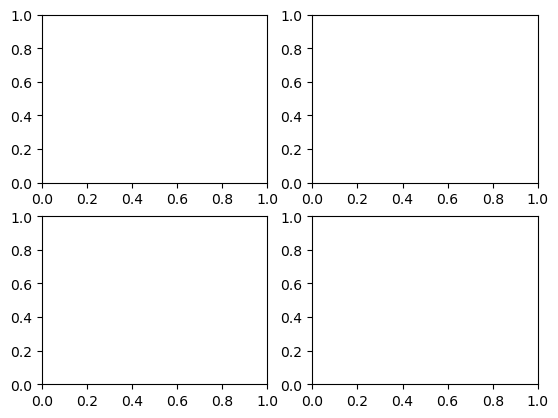

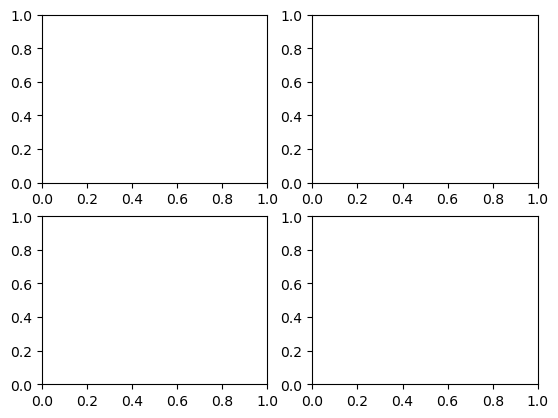

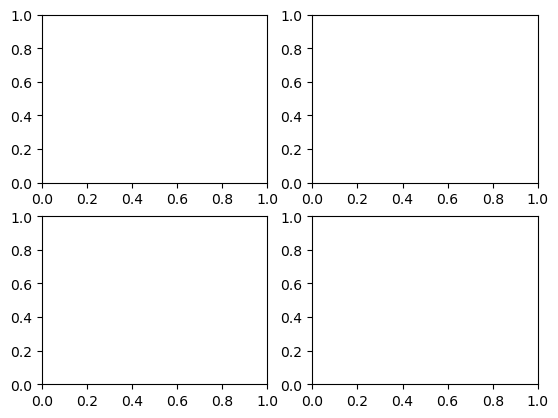

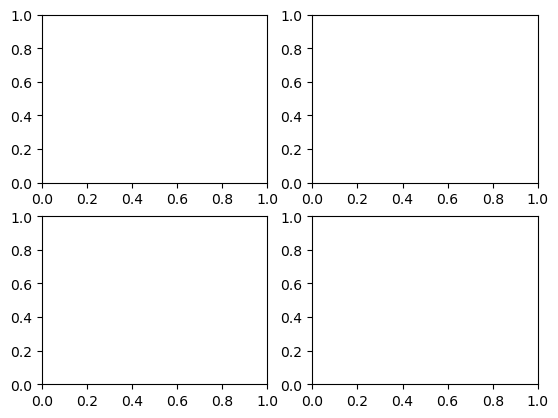

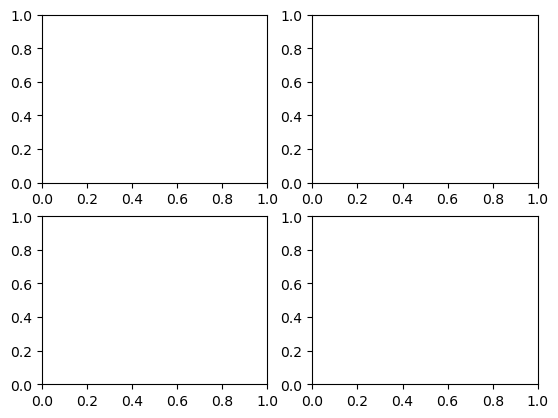

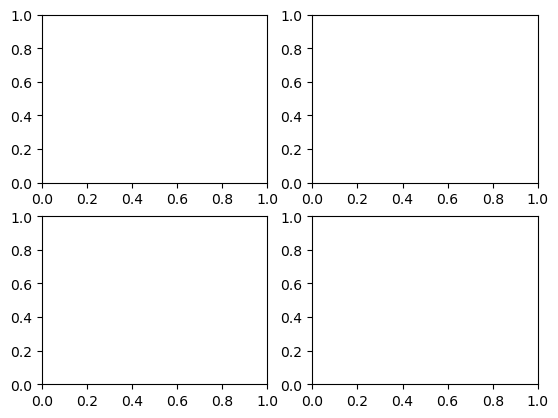

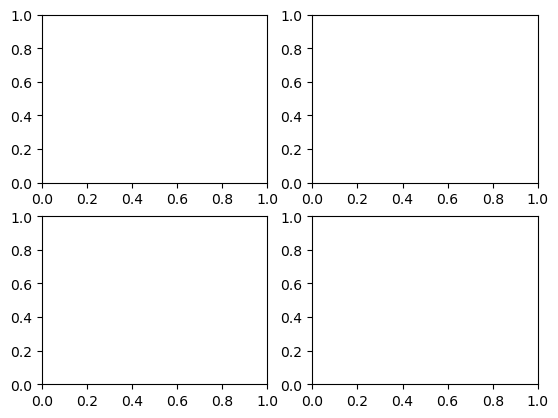

In [2]:
from FIT_python.data_split_and_summary.data_import_wrapper import DataImportWrapper

DataImportWrapper().clean_all()

Overview generation of Datasets in experiment

In [3]:
from FIT_python.data_split_and_summary.dataset_summary import generate_dataset_overview

overview_df = generate_dataset_overview(cfg.RAW_DIR, EXP_DIR/'dataset_overview.parquet')
overview_df

Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

,Species,No. of footprints,No. of known individuals,No. of trails,No. of measurements
0,Amur Tiger (Panthera tigris altaica),605,44,86,128
1,Bengal Tiger (Panthera tigris tigris),586,40,87,128
2,Cheetah (Acinonyx jubatus),781,38,110,135
3,Eurasian Otter (Lutra lutra),628,42,80,205
4,Giant Panda (Ailuropoda melanoleuca),523,42,77,122
5,Lowland Tapir (Tapirus terrestris),426,37,64,90
6,Mountain Lion (Puma concolor),535,35,78,131
7,White Rhinoceros (Ceratotherium simum),1273,41,154,104


Training and Test splits and inference splits
For both sex‐classification and individual‐identification models, the captive dataset of known individuals was randomly divided into training and validation subsets using a script‐based, group‐stratified sampling procedure with a fixed random seed to ensure reproducibility. Stratification guaranteed an even sex ratio across both splits, while grouping by animal prevented any overlap of individuals between training and testset.  Additional Validation folds were created and assigned and later used for hyperparameter optimization.
For the Otters a custom script for generating the folds was used making sure, that dna validated field prints only appeared in the testset, additionally since we had a set of prints in Sand and a set of prints in mud available we made sure that an equal number of individuals of both sexes are present in the testset. Train test splits needs to be executed here as it includes data cleaning steps that otherwise cause errors in the data exploration and visualisations functions that technically come beforehand in the dissertations


Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Splitting datasets:   0%|          | 0/8 [00:00<?, ?it/s]

✔️ Fold-Spalte in amur_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    106
1    102
2    101
3     85
4     83

📊 amur_tiger – train – 477 Zeilen | 35 Individuen | 66 Trails
sex
f    267
m    210

📊 amur_tiger – test – 128 Zeilen | 9 Individuen | 21 Trails
sex
f    77
m    51

📊 amur_tiger – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ amur_tiger gespeichert (parquet)
✔️ Fold-Spalte in bengal_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     81
1     93
2     74
3    117
4     86

📊 bengal_tiger – train – 451 Zeilen | 27 Individuen | 67 Trails
sex
m    274
f    177

📊 bengal_tiger – test – 97 Zeilen | 7 Individuen | 13 Trails
sex
m    54
f    43

📊 bengal_tiger – inference – 38 Zeilen | 6 Individuen | 7 Trails
sex
unknown    38

✅ bengal_tiger gespeichert (parquet)
✔️ Fold-Spalte in cheetah schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    1

...


[DEBUG] compute_summary called for lowlandtapir/inference, df shape = (4, 126)
[DEBUG] ds_label = lowlandtapir Inference
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['tapirus_terrestris']
[DEBUG] species_code = tapirus terrestris
[DEBUG] sex value counts:
sex
Unknown    4
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (0, 126)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Male, subset shape = (0, 126)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Unknown, subset shape = (4, 126)
[DEBUG]  n_fp=4, n_ind=1, n_tr=1
[DEBUG]   fp_per_ind summary: mean=4.0, sd=0.0
[DEBUG]   tr_per_ind summary: mean=1.0, sd=0.0
[DEBUG] Returning summary DataFrame with shape (3, 10)

[DEBUG] compute_summary called for lowlandtapir/test, df shape = (107, 126)
[DEBUG] ds_label = lowlandtapir Test
[DEBUG] speci

Splits:   0%|          | 0/3 [00:00<?, ?it/s]


[DEBUG] compute_summary called for mountain_lion/inference, df shape = (0, 138)
[DEBUG] df is empty, returning empty summary

[DEBUG] compute_summary called for mountain_lion/test, df shape = (110, 138)
[DEBUG] ds_label = mountain_lion Test
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['puma_concolor']
[DEBUG] species_code = puma concolor
[DEBUG] sex value counts:
sex
Female    73
Male      37
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (73, 138)
[DEBUG]  n_fp=73, n_ind=4, n_tr=11
[DEBUG]   fp_per_ind summary: mean=18.25, sd=1.479019945774904
[DEBUG]   tr_per_ind summary: mean=2.75, sd=0.4330127018922193
[DEBUG] sex = Male, subset shape = (37, 138)
[DEBUG]  n_fp=37, n_ind=3, n_tr=5
[DEBUG]   fp_per_ind summary: mean=12.333333333333334, sd=3.858612300930075
[DEBUG]   tr_per_ind summary: mean=1.6666666666666667, sd=0.4714045207910317
[DEBUG] sex = Unknown, subset shape = (0, 138)
[DEBUG] 

Splits:   0%|          | 0/3 [00:00<?, ?it/s]


[DEBUG] compute_summary called for white_rhino/inference, df shape = (0, 117)
[DEBUG] df is empty, returning empty summary

[DEBUG] compute_summary called for white_rhino/test, df shape = (284, 117)
[DEBUG] ds_label = white_rhino Test
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['ceratotherium_simum']
[DEBUG] species_code = ceratotherium simum
[DEBUG] sex value counts:
sex
Male      170
Female    114
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (114, 117)
[DEBUG]  n_fp=114, n_ind=5, n_tr=16
[DEBUG]   fp_per_ind summary: mean=22.8, sd=8.749857141690942
[DEBUG]   tr_per_ind summary: mean=3.2, sd=1.16619037896906
[DEBUG] sex = Male, subset shape = (170, 117)
[DEBUG]  n_fp=170, n_ind=4, n_tr=20
[DEBUG]   fp_per_ind summary: mean=42.5, sd=38.86193510364609
[DEBUG]   tr_per_ind summary: mean=5.5, sd=4.5
[DEBUG] sex = Unknown, subset shape = (0, 117)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   

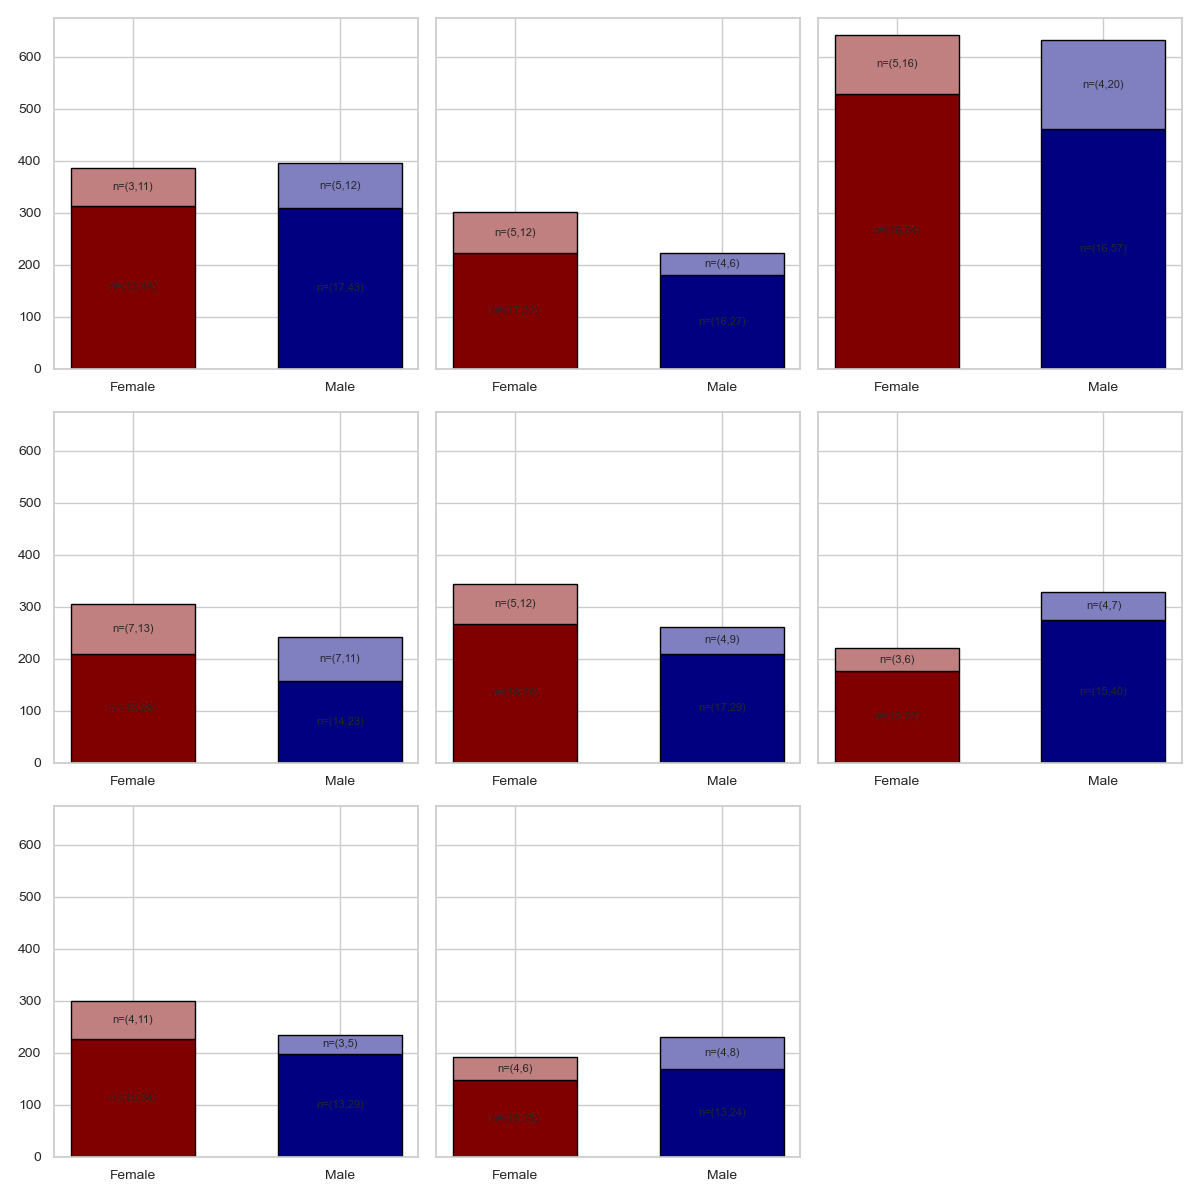

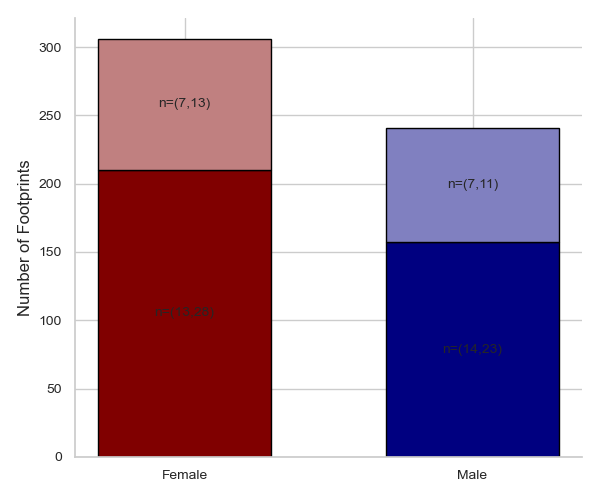

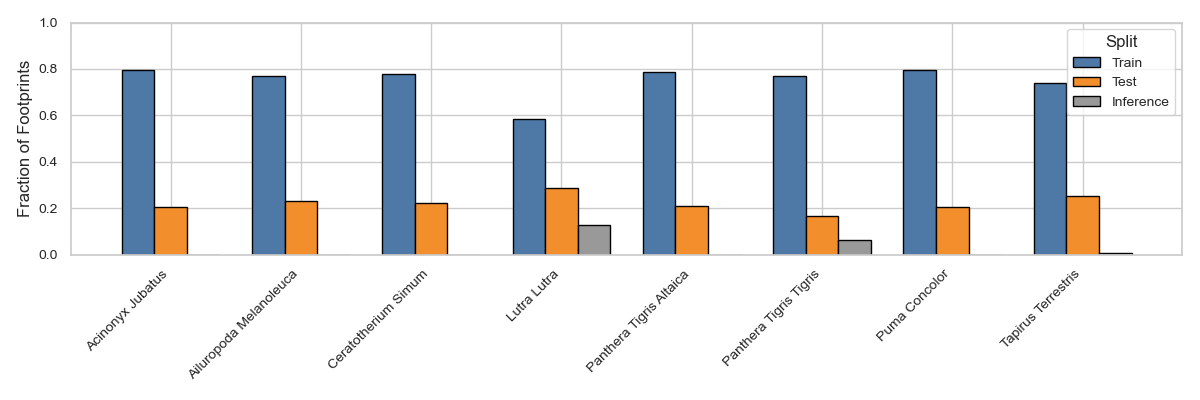

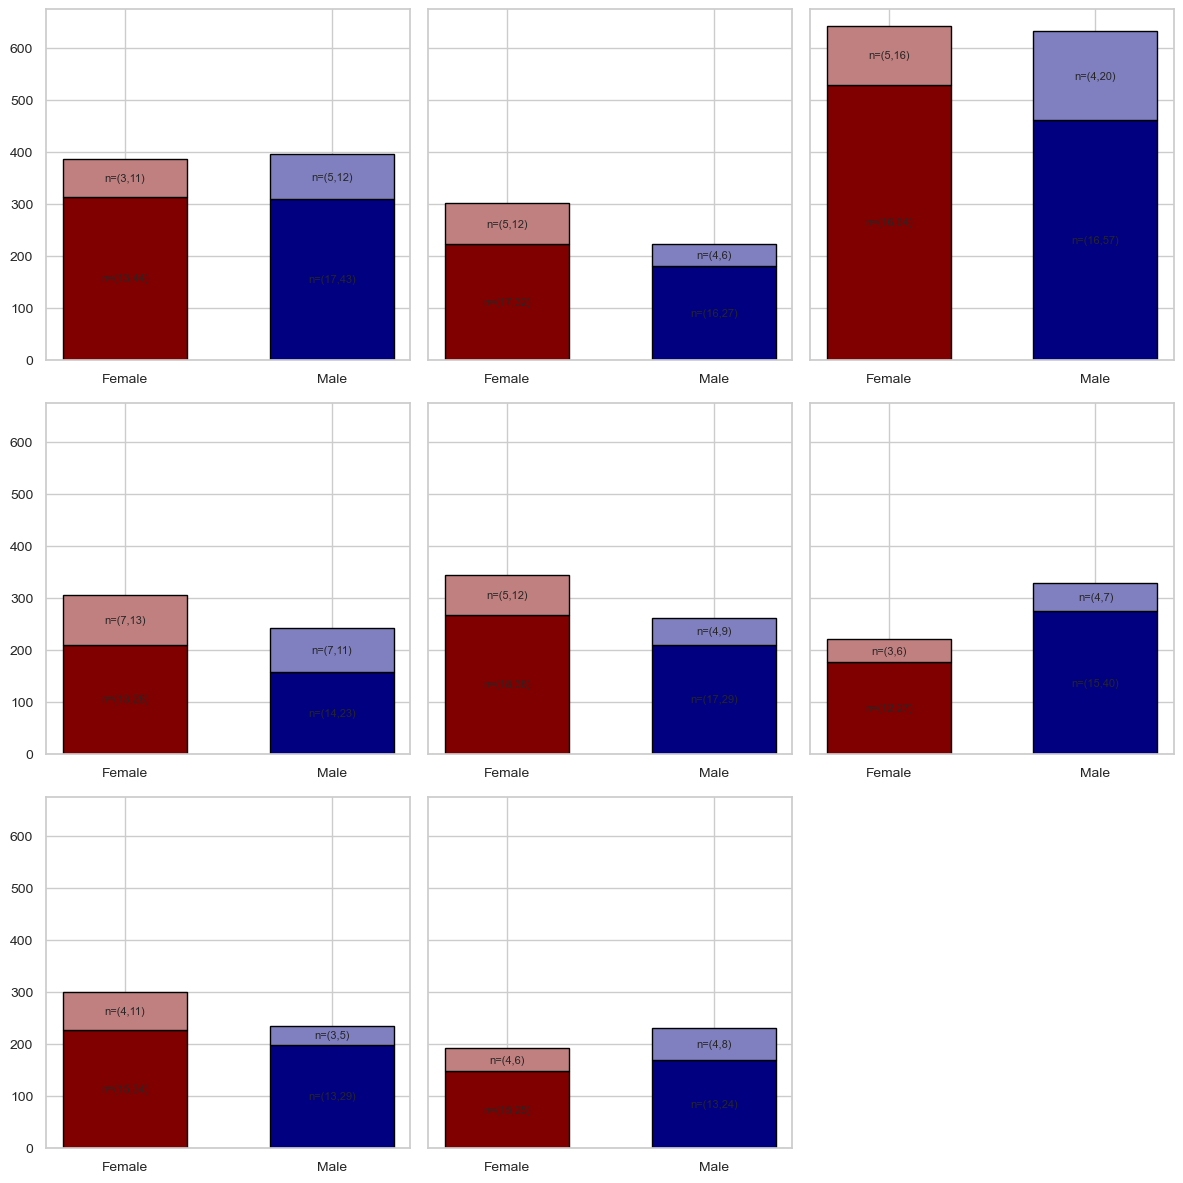

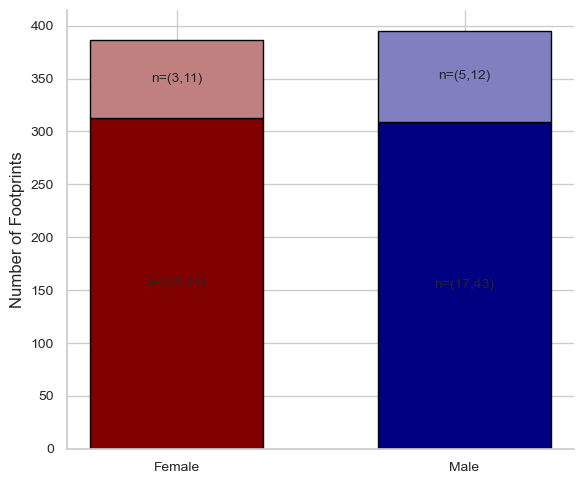

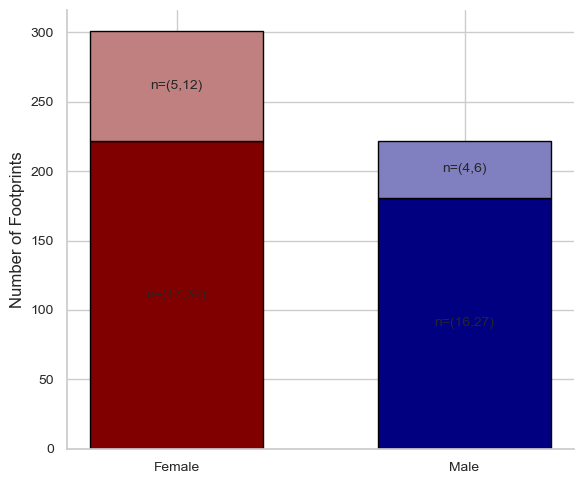

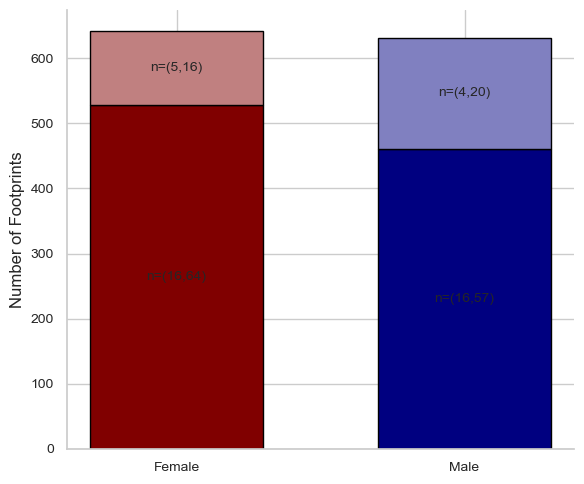

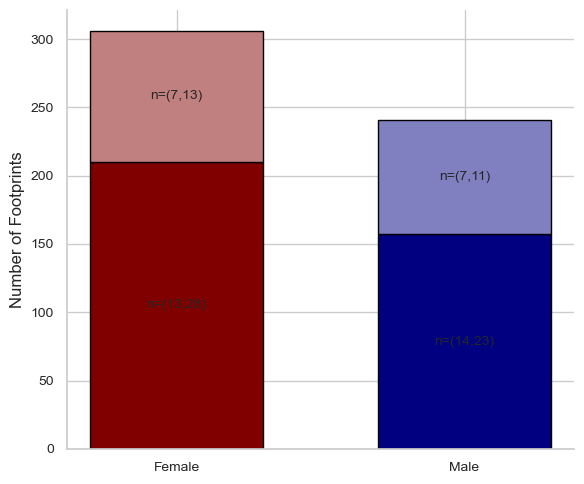

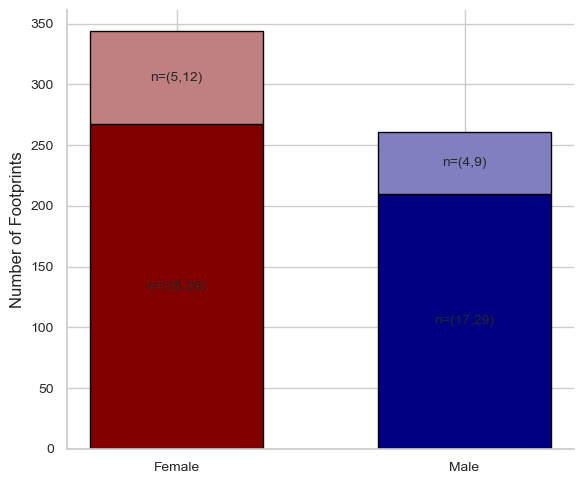

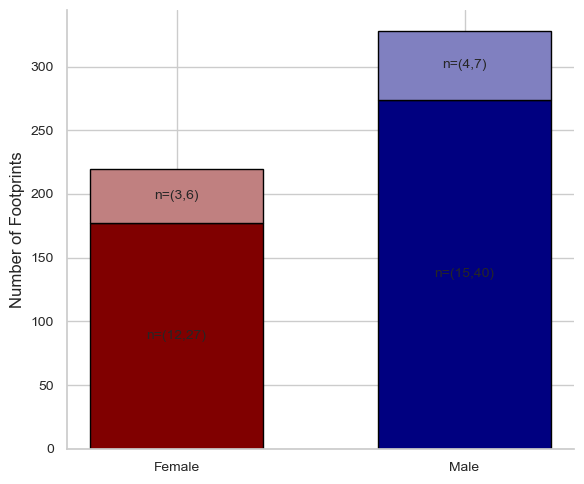

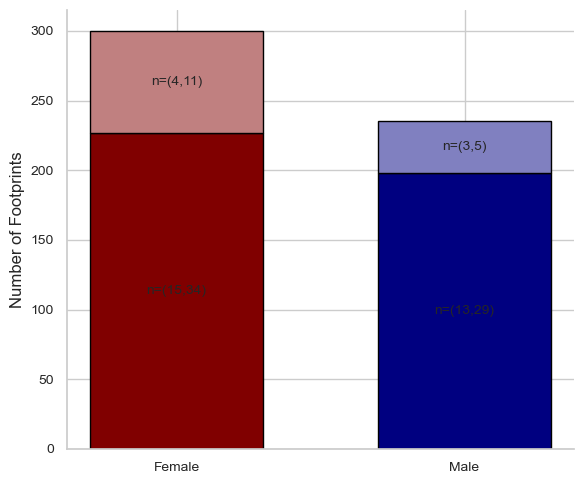

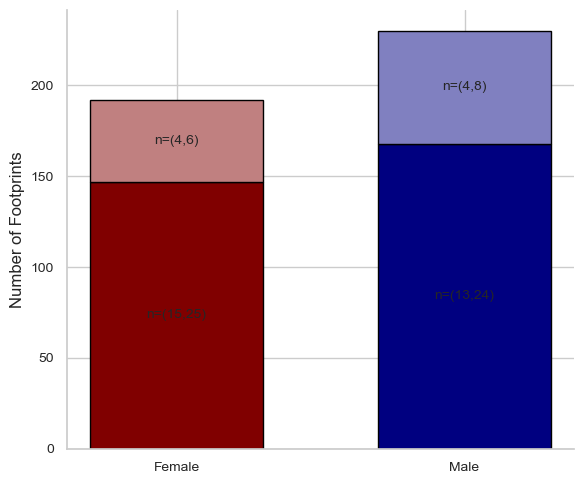

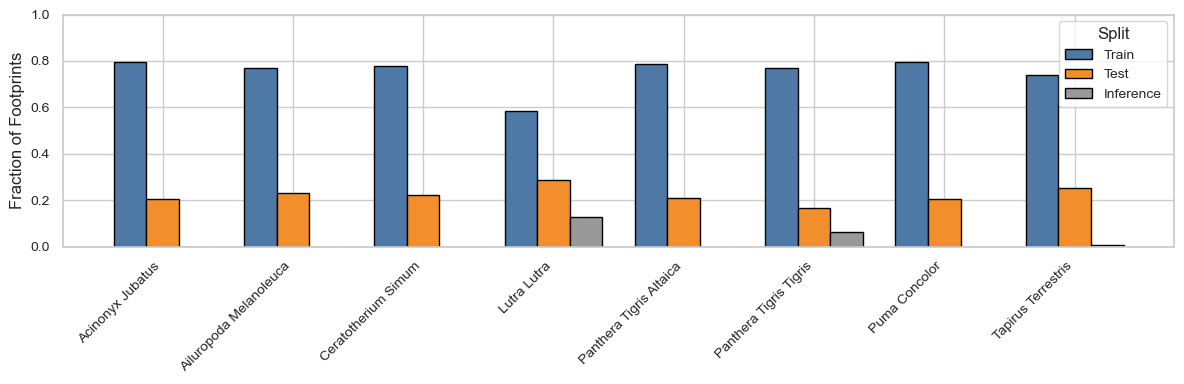

In [4]:

from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from IPython.display import Image, display
import pandas as pd
SplitWrapper().split_all(reuse_splits=True)
run_summary(cfg.SPLITS_DIR, EXP_DIR/'split_summary.csv', EXP_DIR/'split_fig')
display(Image(filename=EXP_DIR/'split_fig/summary_all.png'))
display(Image(filename=EXP_DIR/'split_fig/lutra_lutra_summary.png'))
display(Image(filename=EXP_DIR/'split_fig/split_proportions.png'))



Data Exploration (This step is performed exclusively on the otter data to keep the number of plots manageable.)
With over two hundred measurements extracted from just 11 unique landmarks, we anticipate high correlation among features. Previous FIT publications have shown that using many measurements aids individual identification. However, when the number of measurements far exceeds the number of landmarks, strong correlations between individual measurements emerge.
1.	A correlation matrix (Distances, Angles, Areas) is visualized (see “Correlation Matrix for Eurasian Otters”).
2.	We examine the top four univariate features with the highest separation power for the targets “sex” and “individual_id” on the full otter dataset.
3.	We generate two supervised UMAP embeddings—for “sex” and for “individual_id”—using fivefold cross-validation. Note that these embeddings are for visualization only; all modeling steps described later adhere to a stricter split regime.


In [5]:
from FIT_python.Visualisations.plot_style import map_sex
from FIT_python import config as cfg
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

from FIT_python.Visualisations.plots_utils import (
    plot_feature_correlation_matrix,
    select_top_features,
    plot_sex_boxplots,
    plot_individual_boxplots,
)
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

# Basis-Ordner für Exploration
EXP_DIR = cfg.RESULTS_DATA_DIR / "exploration"

# Pfad zur Datei
file_path = cfg.CLEANED_DIR / "Eurasian_Otter.parquet"

# Unterordner für Data Exploration anlegen
exp_dir_dataexpl = EXP_DIR / "data_exploration_figures"
exp_dir_dataexpl.mkdir(parents=True, exist_ok=True)

# Laden des DataFrames
otter_df = pd.read_parquet(file_path)

# Datenbereinigung
otter_df = otter_df.dropna(subset=['sex', 'individual_id'])
otter_df = otter_df[~otter_df['sex'].astype(str).str.lower().eq('na')]
otter_df = otter_df[~otter_df['individual_id'].astype(str).str.lower().eq('na')]
otter_df['sex_mapped'] = map_sex(otter_df['sex'])

# Top-Features bestimmen
top_sex = select_top_features(otter_df, 'sex', k=4)
top_ind = select_top_features(otter_df, 'individual_id', k=4)

# Plots erzeugen
plot_feature_correlation_matrix(otter_df, exp_dir_dataexpl)


[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.


WindowsPath('c:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/notebooks/results/fit_notebook_fast_2/results_data/exploration/data_exploration_figures/feature_corr_matrix_2x2.png')

➡️ Features gewählt: Sex=dist10_14, Individual=t2_3_5


**individual_boxplots_2x1**

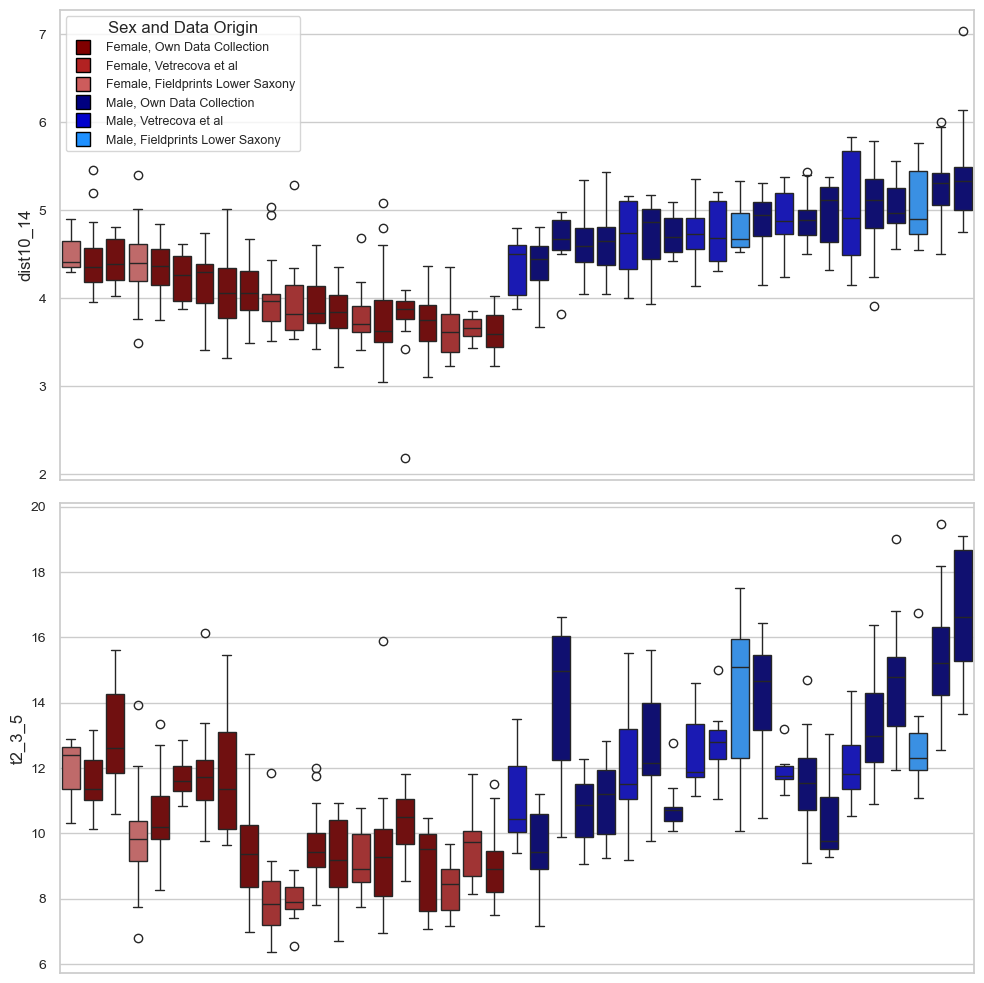

(WindowsPath('c:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/notebooks/results/fit_notebook_fast_2/results_data/exploration/data_exploration_figures/individual_boxplots_2x1.png'),
 ['dist10_14', 't2_3_5'])

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib.lines import Line2D
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols


def plot_individual_boxplots_2x1(df, fig_dir, filename, feature_cols):
    """
    Boxplots für:
    - bestes Sex-Feature
    - bestes Individuen-Feature
    (2x1 Matrix)
    """

    # Filter nur Female/Male und gültige Dataorigins
    df = df[df["sex_mapped"].isin(["Female", "Male"])].copy()
    df = df[df["dataorigin"].isin([
        "Own Data Collection", "Vetrecova et al", "Fieldprints Lower Saxony"
    ])]

    id_col = "individual_id"
    X = df[feature_cols].fillna(df[feature_cols].mean())

    # --- bestes Sex-Feature ---
    le_sex = LabelEncoder().fit(df["sex_mapped"])
    y_sex = le_sex.transform(df["sex_mapped"])
    f_vals_sex, _ = f_classif(X, y_sex)
    best_sex_feat = feature_cols[np.nanargmax(f_vals_sex)]

    # --- bestes Individuum-Feature ---
    le_ind = LabelEncoder().fit(df[id_col])
    y_ind = le_ind.transform(df[id_col])
    f_vals_ind, _ = f_classif(X, y_ind)
    best_ind_feat = feature_cols[np.nanargmax(f_vals_ind)]

    final_feats = [best_sex_feat, best_ind_feat]
    print(f"➡️ Features gewählt: Sex={best_sex_feat}, Individual={best_ind_feat}")

    # Farbpalette
    sex_palette = {
        'Female': ["#800000", "#B22222", "#CD5C5C"],
        'Male':   ["#000080", "#0000CD", "#1E90FF"]
    }
    origin_order = ['Own Data Collection', 'Vetrecova et al', 'Fieldprints Lower Saxony']

    def assign_color(row):
        palette = sex_palette[row['sex_mapped']]
        idx = origin_order.index(row['dataorigin']) % len(palette)
        return palette[idx]

    df["color"] = df.apply(assign_color, axis=1)
    color_dict = df.groupby(id_col)["color"].first().to_dict()

    # Sortierung nach Sex-Feature
    female_means = (
        df[df["sex_mapped"] == "Female"]
        .groupby(id_col)[best_sex_feat].mean()
        .sort_values(ascending=False)
    )
    male_means = (
        df[df["sex_mapped"] == "Male"]
        .groupby(id_col)[best_sex_feat].mean()
        .sort_values(ascending=True)
    )
    ind_order = female_means.index.tolist() + male_means.index.tolist()

    # --- Plot ---
    display(Markdown(f"**{filename.replace('.png','')}**"))
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    for ax, feat in zip(axes, final_feats):
        sns.boxplot(
            data=df,
            x=id_col,
            y=feat,
            ax=ax,
            hue=id_col,
            palette=color_dict,
            dodge=False,
            order=ind_order,
            legend=False,
        )
        ax.set_xlabel("")
        ax.set_xticks([])
        ax.set_ylabel(feat)

    # Legende
    legend_elements = []
    for sex in ["Female", "Male"]:
        for i, origin in enumerate(origin_order):
            color = sex_palette[sex][i % len(sex_palette[sex])]
            legend_elements.append(Line2D(
                [0], [0], marker='s', color='w',
                label=f"{sex}, {origin}",
                markerfacecolor=color, markersize=10,
                markeredgecolor='black'
            ))
    axes[0].legend(
        handles=legend_elements,
        title="Sex and Data Origin",
        loc="upper left",
        fontsize=9
    )

    plt.tight_layout()
    save_path = fig_dir / filename
    fig.savefig(save_path, dpi=150)
    plt.show()

    return save_path, final_feats


feature_cols = get_feature_cols(otter_df)
# --- Aufruf ---
plot_individual_boxplots_2x1(
    df=otter_df,
    fig_dir=exp_dir_dataexpl,
    filename="individual_boxplots_2x1.png",
    feature_cols=feature_cols
)



Visualisierung mit Umap alle Otter

c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Frede\AppData\Local\Temp\ipykernel_8784\900061912.py:66: UserWarning: You passed a edgecolor/edgecolors ('black') for an unf

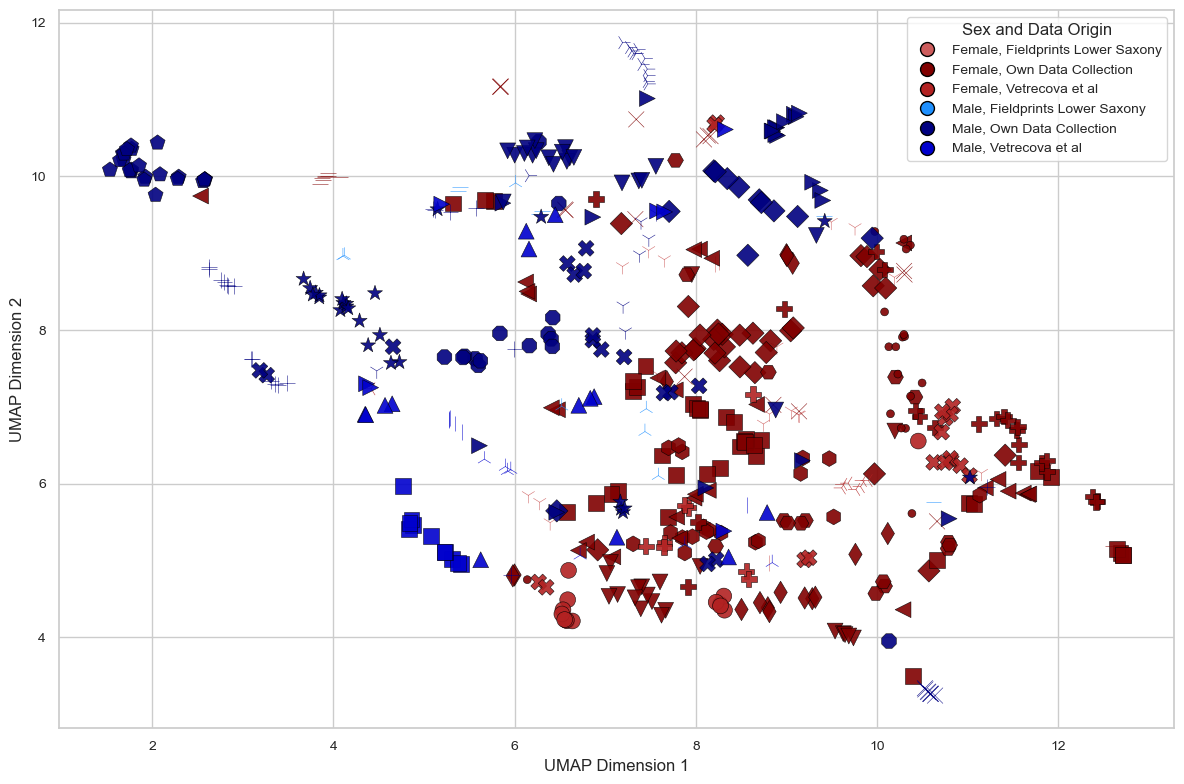

In [7]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import itertools
from matplotlib.lines import Line2D
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer


# --------------------------------
# Embedding erzeugen
# --------------------------------
# Nur gewünschte Dataorigins filtern
otter_df = otter_df[otter_df['dataorigin'].isin([
    'Vetrecova et al', 'Own Data Collection', 'Fieldprints Lower Saxony'
])]

# Features bestimmen und numerisch umwandeln
features = get_feature_cols(otter_df)
otter_df = convert_numeric(otter_df, features)
X = otter_df[features].astype(float)

# supervised UMAP mit Individual-ID und festem Seed
dr = DimensionalityReducerTransformer(
    method='umap',
    supervised=True,
    random_state=42    # Seed für Reproduzierbarkeit
)
emb = dr.fit_transform(X, otter_df['individual_id'])

# DataFrame mit Embedding und Metadaten
emb_df = pd.DataFrame(emb, index=otter_df.index, columns=dr.get_feature_names_out())
emb_df = emb_df.assign(
    individual_id=otter_df['individual_id'],
    sex_mapped=otter_df['sex'].map({'f':'Female', 'F':'Female', 0:'Female',
                                    'm':'Male', 'M':'Male', 1:'Male'}),
    dataorigin=otter_df['dataorigin']
)
# Marker-Liste für viele Individuen
markers = ['o', 's', '^', 'v', '<', '>', 'P', 'X', 'D', '*', '+', 'x', '|', '_',
           '1', '2', '3', '4', '8', 'p', 'H', 'h', 'd', '.', ',']
marker_cycle = itertools.cycle(markers)
unique_individuals = emb_df['individual_id'].unique()
marker_map = {ind: next(marker_cycle) for ind in unique_individuals}

# Kräftigere Farbpaletten für Sex mit klareren Schattierungen
sex_palette = {
    'Female': ["#800000", "#B22222", "#CD5C5C"],   # Dunkelrot → Rot → Hellrot
    'Male': ["#000080", "#0000CD", "#1E90FF"]      # Navy → Mittelblau → Hellblau
}
origin_order = ['Own Data Collection', 'Vetrecova et al', 'Fieldprints Lower Saxony']

# Farbe zuweisen basierend auf Sex und Data Origin
def assign_color(row):
    palette = sex_palette[row['sex_mapped']]
    idx = origin_order.index(row['dataorigin']) % len(palette)
    return palette[idx]

emb_df['color'] = emb_df.apply(assign_color, axis=1)

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 8))
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    for ind, subgroup in group.groupby('individual_id'):
        ax.scatter(
            subgroup['UMAP1'], subgroup['UMAP2'],
            c=subgroup['color'],
            marker=marker_map[ind],
            s=130,          # Noch größere Marker
            alpha=0.9,
            edgecolor='black',
            linewidth=0.4
        )

# Achsenbeschriftungen
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")

# Legende nur mit Kreisen
from matplotlib.lines import Line2D
legend_elements = []
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    legend_elements.append(Line2D(
        [0], [0], marker='o', color='w', label=f"{sex}, {origin}",
        markerfacecolor=group['color'].iloc[0], markersize=10, markeredgecolor='black'
    ))

ax.legend(handles=legend_elements, title="Sex and Data Origin", fontsize=10)

plt.tight_layout()

# Speichern
fig_path = Path(exp_dir_dataexpl) / "umap_individuals_sex_origin_bigmarkers_simplelegend.png"
plt.savefig(fig_path, dpi=300)
plt.show()


Training sex Model

In [8]:
# ────────────────────────────────────────────────────────────────
# Sex Classification: Model Training with Bayesian Optimisation
# ────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier  # Optional, falls CatBoost aktiv
from FIT_python.pipeline_sex.sex_config import run_otter_search_sex, run_other_species_search
from FIT_python.pipeline_sex import collect_best_metrics
import FIT_python.config as cfg

# deine vorhandenen Helper
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric

# ─── Models Definition ───────────────────────────────────────────
# ─── Models Definition (LDA, Logistic Regression, XGBoost Variants) ──────────
MODELS = {
    # Logistic Regression Variants
    "logreg_l2": LogisticRegression(
        penalty="l2", solver="lbfgs", C=1.0, max_iter=500
    ),
    "logreg_l1": LogisticRegression(
        penalty="l1", solver="saga", C=1.0, max_iter=500
    ),

    # LDA Baseline
    "lda": LinearDiscriminantAnalysis(),

    # XGBoost Variants
    "xgb_std": XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_deep": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=10,
        subsample=0.9, colsample_bytree=0.9,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_fast": XGBClassifier(
        n_estimators=50, learning_rate=0.2, max_depth=4,
        subsample=0.8, colsample_bytree=0.7,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_reg": XGBClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=6,
        reg_alpha=0.1, reg_lambda=1.0,
        subsample=0.85, colsample_bytree=0.85,
        use_label_encoder=False, verbosity=0
    ),
}
# BayesSearchCV ausführen (legt automatisch species-bezogene Unterordner an)
run_otter_search_sex(reuse_results=False)       # Otter
run_other_species_search()   # alle übrigen Spezies

# Zusammenfassung der besten Modelle für Auswertung und Visualisierung
summary_df = collect_best_metrics(cfg.RESULTS_DATA_DIR)

eurasian_otter BS-CV:   0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.296e-03, tolerance: 5.995e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.300e-02, tolerance: 5.995e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale

✅ Modell für Spezies 'eurasian_otter', Kriterium 'accuracy' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\results_data\eurasian_otter\models\accuracy\eurasian_otter.joblib


...

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.108e-02, tolerance: 1.503e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.490e-02, tolerance: 1.503e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale

✅ Modell für Spezies 'white_rhino', Kriterium 'accuracy' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\results_data\white_rhino\models\accuracy\white_rhino.joblib
✅ Modell für Spezies 'white_rhino', Kriterium 'balanced_accuracy' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\results_data\white_rhino\models\balanced_accuracy\white_rhino.joblib


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.384e-02, tolerance: 1.503e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.987e-02, tolerance: 1.503e-02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale

✅ Modell für Spezies 'white_rhino', Kriterium 'neg_log_loss' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\results_data\white_rhino\models\neg_log_loss\white_rhino.joblib
✅ Modell für Spezies 'white_rhino', Kriterium 'f1' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\results_data\white_rhino\models\f1\white_rhino.joblib
✅ Modell für Spezies 'white_rhino', Kriterium 'precision' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\results_data\white_rhino\models\precision\white_rhino.joblib
✅ Modell für Spezies 'white_rhino', Kriterium 'recall' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\results_data\white_rhino\models\recall\white_rhino.joblib
✅ Modell für Spezies 'white_rhino', Kriterium 'roc

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import importlib

# ---------------------------------------------------------------------
# Projekt-Setup
# ---------------------------------------------------------------------
from FIT_python import config
importlib.reload(config)

# Ergebnisse-Verzeichnis suchen
base_dir = config.RESULTS_DATA_DIR
if not base_dir.exists():
    alt_dir = config.EXPERIMENT_ROOT / r"\results_data\eurasian_otter\search"
    if alt_dir.exists():
        base_dir = alt_dir
    else:
        raise FileNotFoundError(
            f"Kein gültiges Ergebnis-Verzeichnis gefunden:\n"
            f"- {config.RESULTS_DATA_DIR}\n- {alt_dir}"
        )

benchmark_dir = config.EXPERIMENT_ROOT / "benchmark"
benchmark_dir.mkdir(parents=True, exist_ok=True)

print("Experiment root:", config.EXPERIMENT_ROOT)
print("Base data dir:", base_dir)
print("Benchmark dir:", benchmark_dir)

# Einsammeln
benchmark_rows = []
for species_dir in base_dir.iterdir():
    if not species_dir.is_dir():
        continue
    best_csv = species_dir / "best_models.csv"
    all_csv = species_dir / "all_results.csv"
    if not (best_csv.exists() and all_csv.exists()):
        print(f"⚠️ Fehlen CSV-Dateien in {species_dir.name}, überspringe.")
        continue

    df_all = pd.read_csv(all_csv)
    if "balanced_test_acc" not in df_all.columns:
        print(f"⚠️ Keine Balanced Accuracy (Test) für {species_dir.name}, überspringe.")
        continue

    best_row = (
        df_all.sort_values("balanced_test_acc", ascending=False)
              .iloc[0]
              .to_dict()
    )
    best_row["species"] = species_dir.name  # Spezies anhängen
    benchmark_rows.append(best_row)

benchmark_df = pd.DataFrame(benchmark_rows)
if benchmark_df.empty:
    raise RuntimeError(
        f"Keine validen Ergebnisse in {base_dir} gefunden. "
        "Struktur: species/*(best_models.csv, all_results.csv)"
    )

# Spalten sauber benennen (Test und CV getrennt)
col_map = {
    "species": "Species",
    "balanced_test_acc": "Balanced Accuracy (Test)",
    "accuracy_test": "Accuracy (Test)",
    "maj_test_pct": "Majority Vote Individual Accuracy (Test)",
    "female_test_acc": "Female Accuracy (Test)",
    "male_test_acc": "Male Accuracy (Test)",
    "mean_test_accuracy": "Accuracy (CV)",
    "mean_test_balanced_accuracy": "Balanced Accuracy (CV)",
    "mean_test_neg_log_loss": "Log Loss (CV)",
}

cols_to_keep = [c for c in col_map if c in benchmark_df.columns]
benchmark_df = benchmark_df[cols_to_keep].rename(columns=col_map)

benchmark_df["Species"] = (
    benchmark_df["Species"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

sort_col = (
    "Balanced Accuracy (Test)"
    if "Balanced Accuracy (Test)" in benchmark_df.columns
    else benchmark_df.columns[1]
)

benchmark_df = benchmark_df.round(3).sort_values(sort_col, ascending=False)

# Speichern
out_path = benchmark_dir / "benchmark_summary_best_test.csv"
benchmark_df.to_csv(out_path, index=False)
print(f"✅ Benchmark-Tabelle gespeichert unter: {out_path}")
display(benchmark_df)

# Plot
sns.set_style("whitegrid")
metrics_for_plot = [c for c in benchmark_df.columns if c != "Species"]
palette = sns.color_palette("colorblind", n_colors=len(metrics_for_plot))

ax = benchmark_df.set_index("Species")[metrics_for_plot].plot(
    kind="bar", figsize=(14, 7), color=palette
)
ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Species", fontsize=12)
ax.legend(title="Metric", fontsize=10)
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig(benchmark_dir / "benchmark_summary_best_test_plot.png", dpi=300)
plt.show()


Experiment root: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2
Base data dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\results_data
Benchmark dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\benchmark
⚠️ Fehlen CSV-Dateien in amur_tiger, überspringe.
⚠️ Fehlen CSV-Dateien in bengal_tiger, überspringe.
⚠️ Fehlen CSV-Dateien in cheetah, überspringe.
⚠️ Fehlen CSV-Dateien in eurasian_otter, überspringe.
⚠️ Fehlen CSV-Dateien in eurasian_otter_bayes_search_standard_metrics, überspringe.
⚠️ Fehlen CSV-Dateien in exploration, überspringe.
⚠️ Fehlen CSV-Dateien in giant_panda, überspringe.
⚠️ Fehlen CSV-Dateien in lowlandtapir, überspringe.
⚠️ Fehlen CSV-Dateien in mountain_lion, überspringe.
⚠️ Fehlen CSV-Dateien in panthera_tigris_altaica, überspringe.
⚠️ Fehlen CSV-Dateien in pipeline_cache, überspringe.
⚠️ Fehlen CSV-Datei

RuntimeError: Keine validen Ergebnisse in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\results_data gefunden. Struktur: species/*(best_models.csv, all_results.csv)

Verteilung nach Splits:
__split__
train        367
test         180
inference     81
Name: count, dtype: int64 



,id,species,individual_id,date,location,dataorigin,substrate,sex,trail,dist1_2,...,t12_13_15,t13_14_15,t13_14_17,t12_15_17,t13_14_16,Fold,__split__,pred_sex,pred_proba_f,pred_proba_m
0,1978,lutra_lutra,sylvestr,None,ZOO Ohrada,Vetrecova et al,Mud,m,sylvestr,2.100437,...,40.805568,40.805568,20.670746,19.846014,15.476031,4.0,train,m,0.4,0.6
1,1979,lutra_lutra,sylvestr,None,ZOO Ohrada,Vetrecova et al,Mud,m,sylvestr,2.105151,...,40.178026,40.178026,19.022751,19.041819,13.538922,4.0,train,m,0.4,0.6
2,1980,lutra_lutra,sylvestr,None,ZOO Ohrada,Vetrecova et al,Mud,m,sylvestr,1.994131,...,36.681660,36.681660,19.153493,16.935993,13.553384,4.0,train,m,0.3,0.7
3,1981,lutra_lutra,sylvestr,None,ZOO Ohrada,Vetrecova et al,Mud,m,sylvestr,2.176132,...,38.966133,38.966133,19.602610,17.929819,13.997114,4.0,train,m,0.0,1.0
4,1982,lutra_lutra,sylvestr,None,ZOO Ohrada,Vetrecova et al,Mud,m,sylvestr,2.089009,...,37.394700,37.394700,20.199829,17.286324,14.382585,4.0,train,m,0.4,0.6


Experiment root: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2
Sex plot directory: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\Sex_plots


C:\Users\Frede\AppData\Local\Temp\ipykernel_8784\1083820718.py:54: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


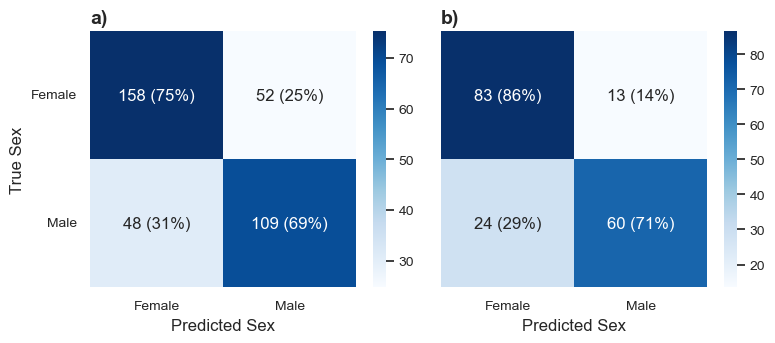

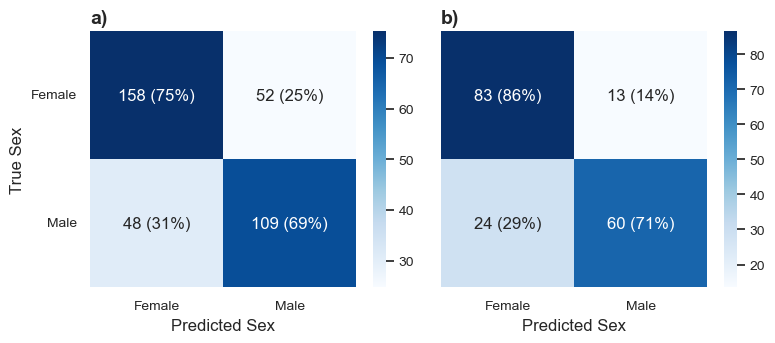

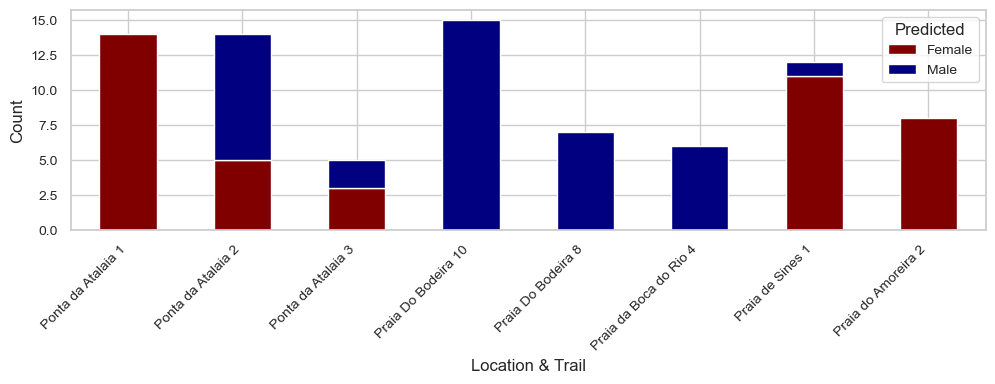

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

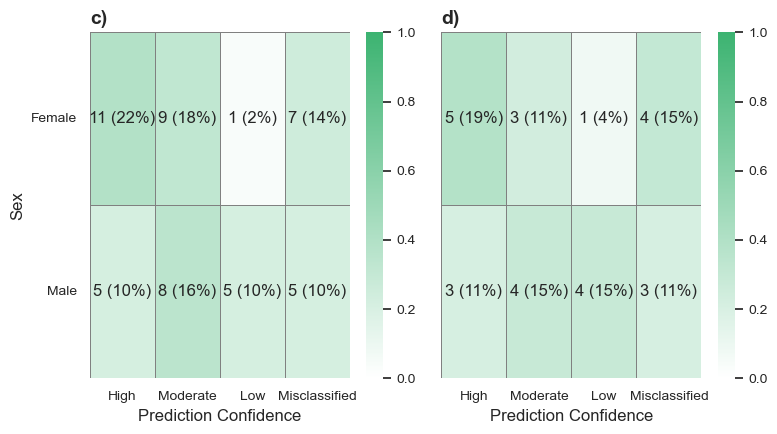

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

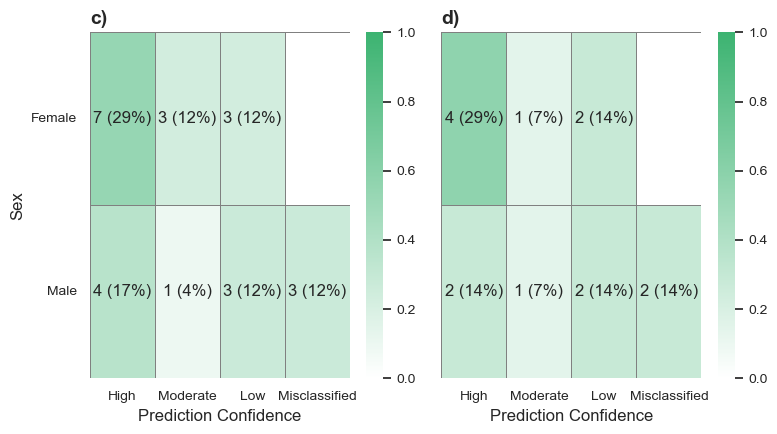

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


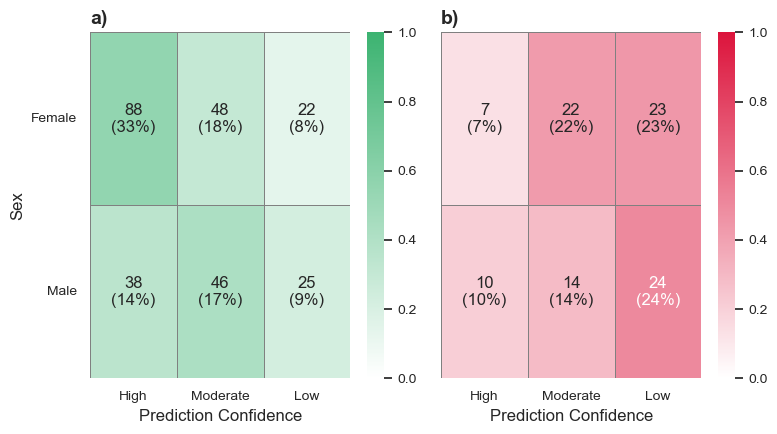

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


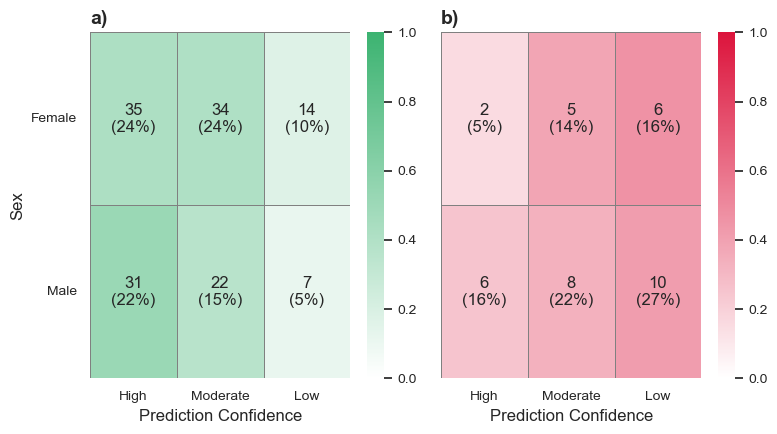

✅ Ergebnisse und Plots gespeichert in: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\Sex_plots


In [31]:
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    predict_all, 
    plot_inference
)
import pandas as pd
import numpy as np
from pathlib import Path
import os, importlib
# --- Inference-Plot erzeugen ---
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    plot_confusion_and_inference, 
    plot_quality_grouped, 
    plot_quality_heatmaps, 
    plot_individual_probabilities, 
    plot_confusion
)
from FIT_python import config
import importlib
import pandas as pd
from pathlib import Path
# ---------------------------------------------------------------------
# Config laden
# ---------------------------------------------------------------------
from FIT_python import config
importlib.reload(config)

# === Konfiguration ===
DEFAULT_SPECIES = "eurasian_otter"
METRIC_KEY = "roc_auc"     
           

# --- Verzeichnis mit den besten Modellen (aus config) ---

# CSV neu erzeugen inkl. Inference mit OOF für Train
df_all = predict_all(
    species=DEFAULT_SPECIES,
    metric_key=METRIC_KEY,          # wichtig!
    prefer_generic=False,
    include_inference=True,
    reuse_csv=False,
    use_cv_train_predictions=True
)

# --- Verteilung Train / Test / Inference prüfen ---
print("Verteilung nach Splits:")
print(df_all["__split__"].value_counts(), "\n")

# --- Kopf zur Kontrolle ---
display(df_all.head())

# --- Mapping Sex-Werte vereinheitlichen ---
sex_mapping = {"F": 0, "M": 1, "f": 0, "m": 1}
if "pred_sex" in df_all.columns:
    df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)



# Config neu laden (falls im gleichen Notebook mehrfach geändert wird)
importlib.reload(config)

# --- Basisverzeichnis aus config ---
base_dir = config.EXPERIMENT_ROOT
sex_dir = base_dir / "Sex_plots"
sex_dir.mkdir(parents=True, exist_ok=True)

print("Experiment root:", base_dir)
print("Sex plot directory:", sex_dir)

# --- Plots erzeugen ---
plot_confusion(df_all)
plot_confusion_and_inference(df_all)
plot_quality_grouped(df_all)   # a) Trail level, b) Individual level
plot_quality_heatmaps(df_all)
# Optional mit Ausgabeordner:
# plot_individual_probabilities(df_all, out_dir=sex_dir)

print(f"✅ Ergebnisse und Plots gespeichert in: {sex_dir}")


Confusion matrix Train und testset

Baseline Model mit basis FIT parameter


📊 Running prediction & plots for metric: accuracy


C:\Users\Frede\AppData\Local\Temp\ipykernel_8784\1749748555.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


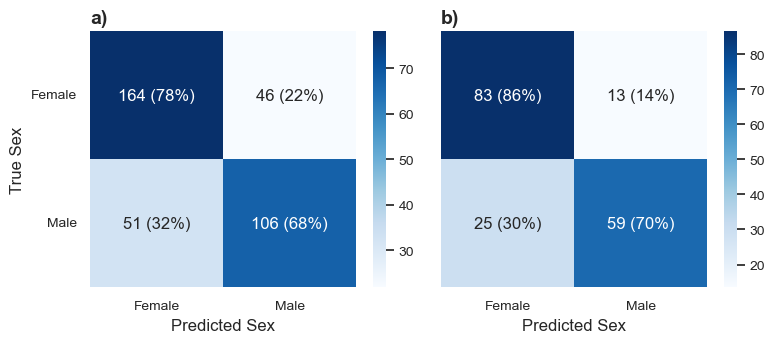

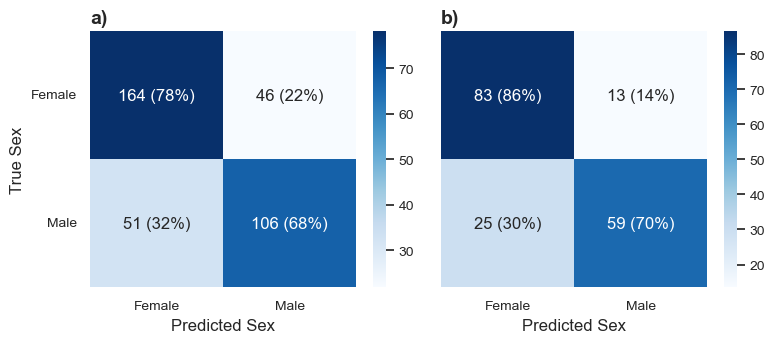

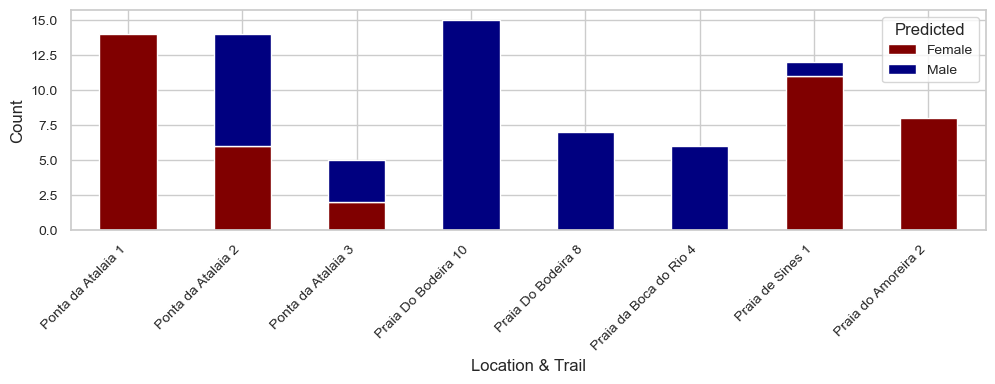

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

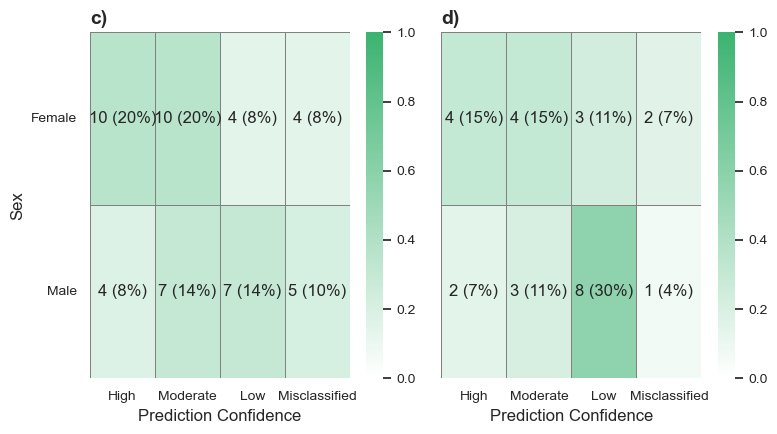

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

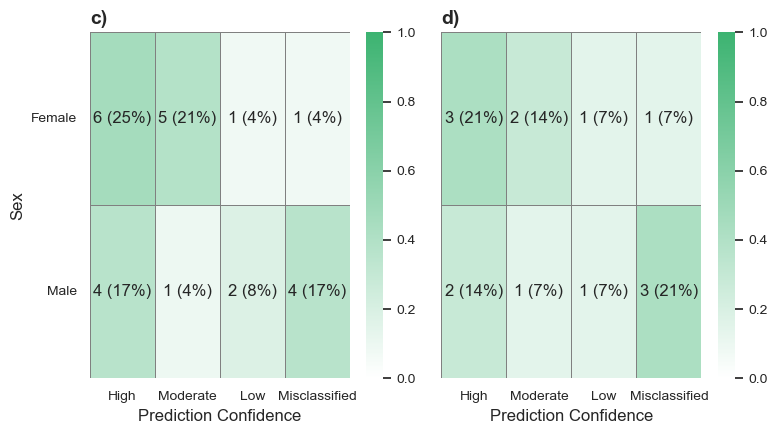

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


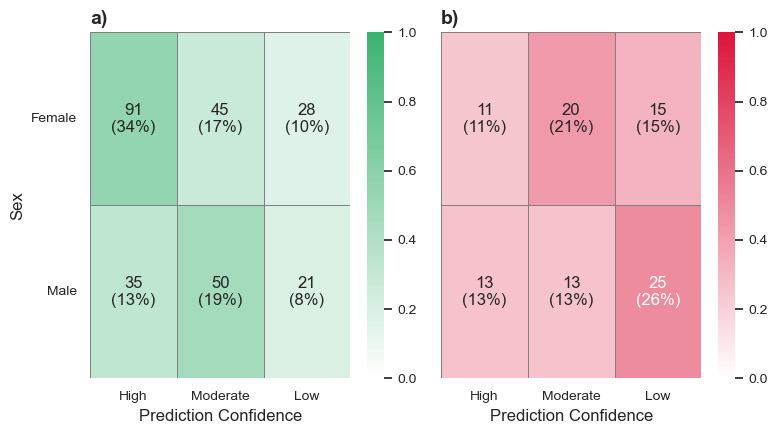

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


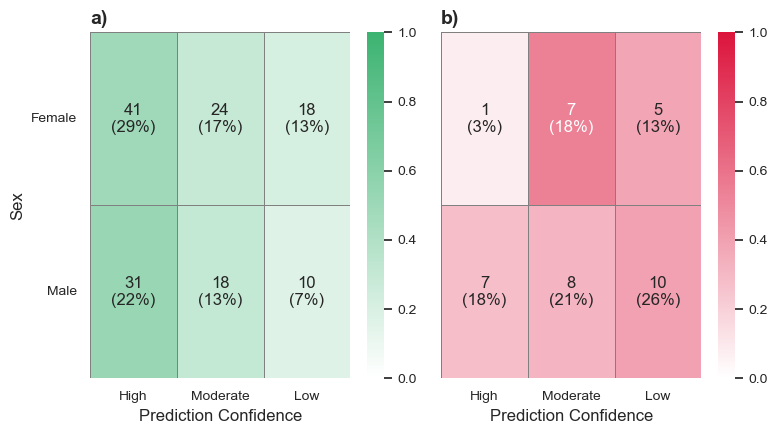

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für accuracy gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\Sex_plots\accuracy

📊 Running prediction & plots for metric: balanced_accuracy


C:\Users\Frede\AppData\Local\Temp\ipykernel_8784\1749748555.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


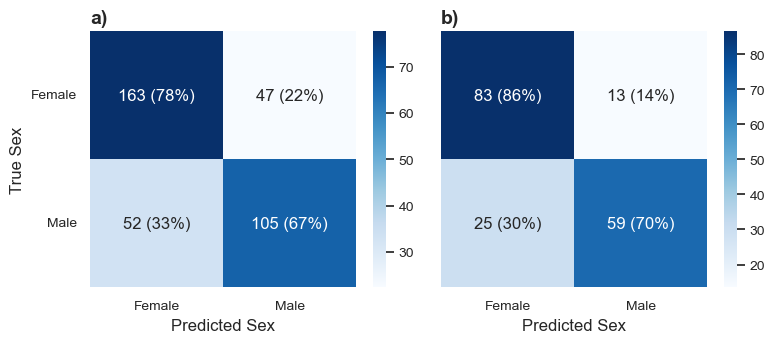

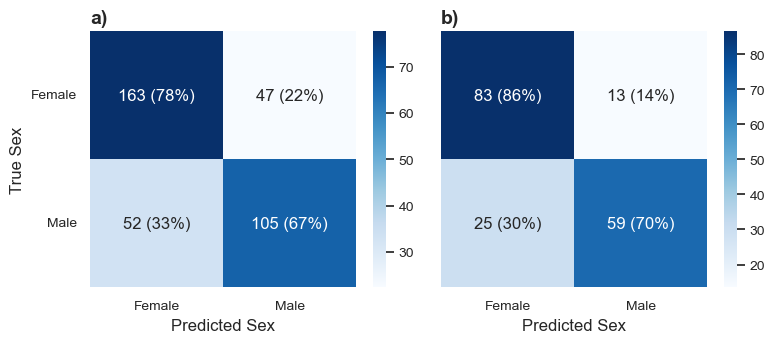

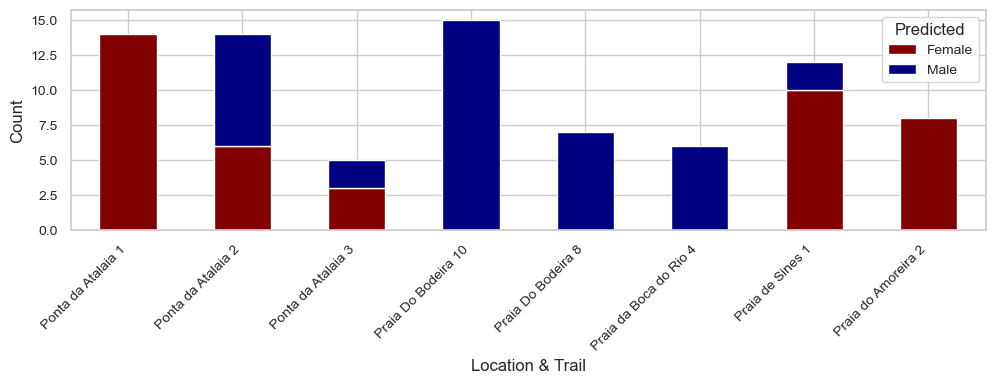

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

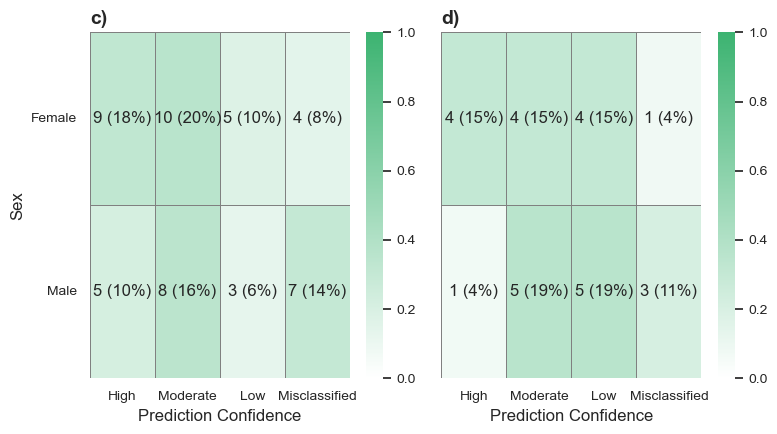

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

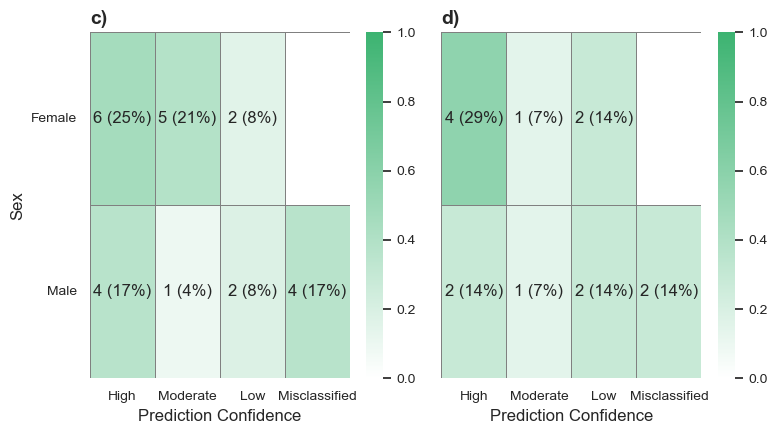

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


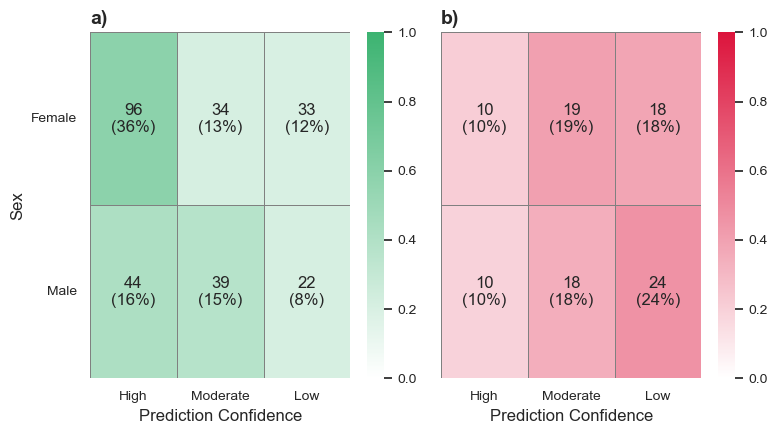

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


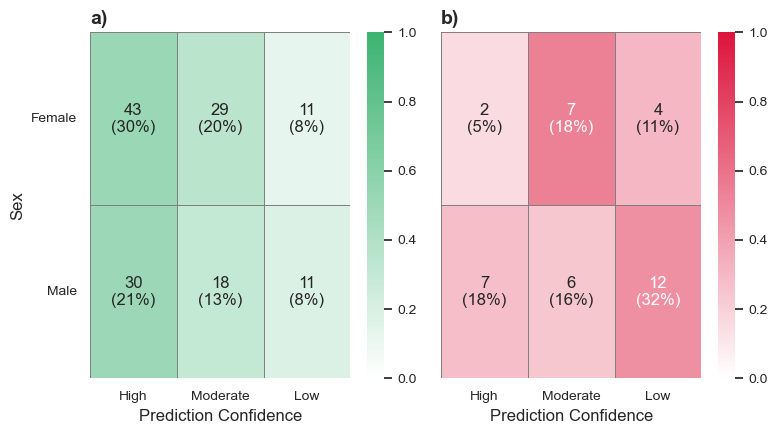

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für balanced_accuracy gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\Sex_plots\balanced_accuracy

📊 Running prediction & plots for metric: neg_log_loss


C:\Users\Frede\AppData\Local\Temp\ipykernel_8784\1749748555.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


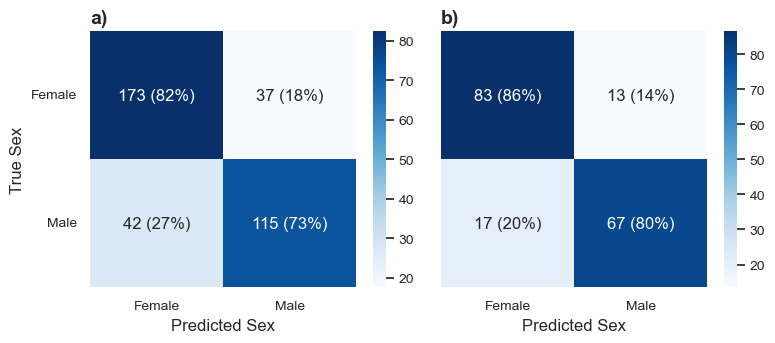

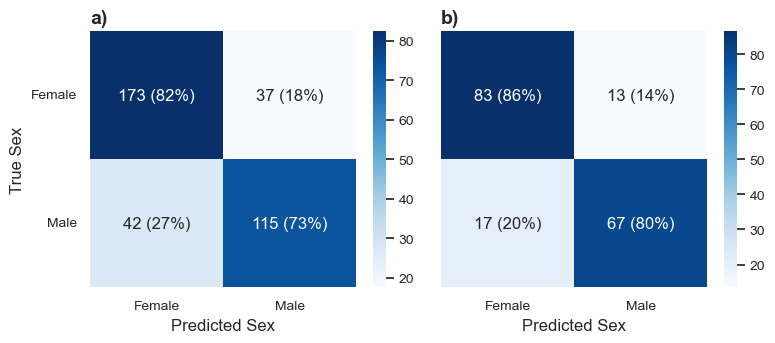

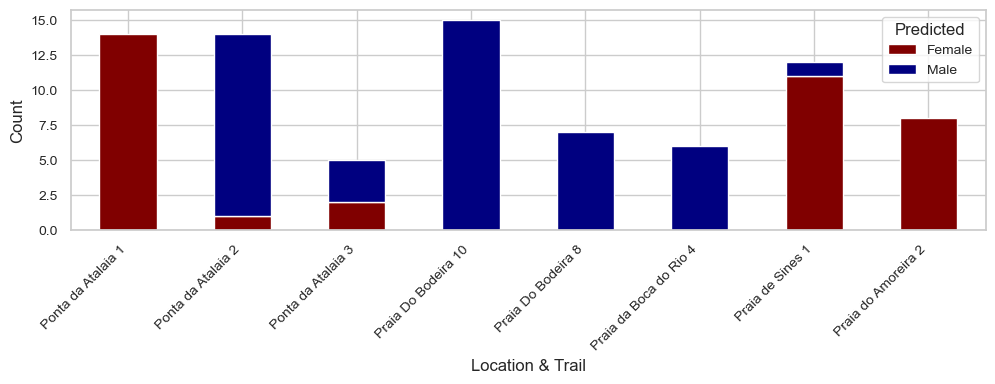

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

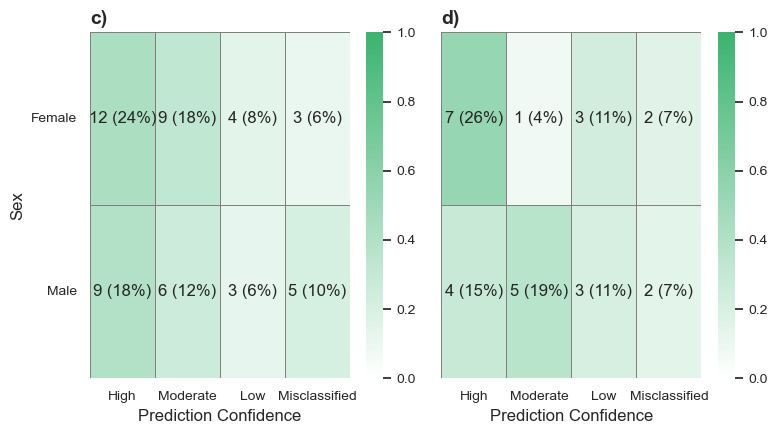

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

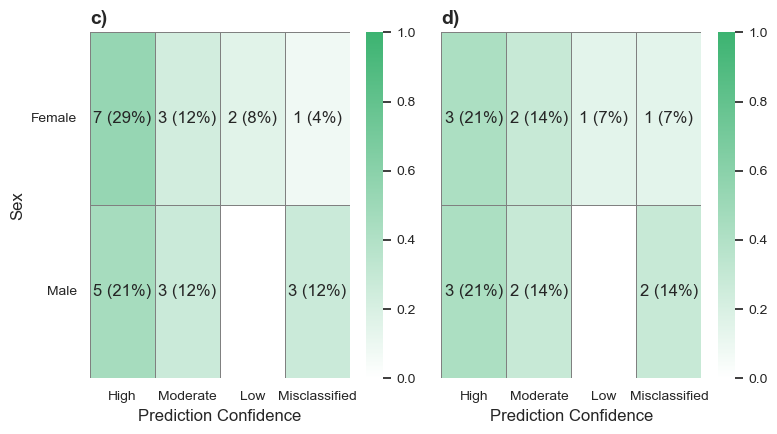

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


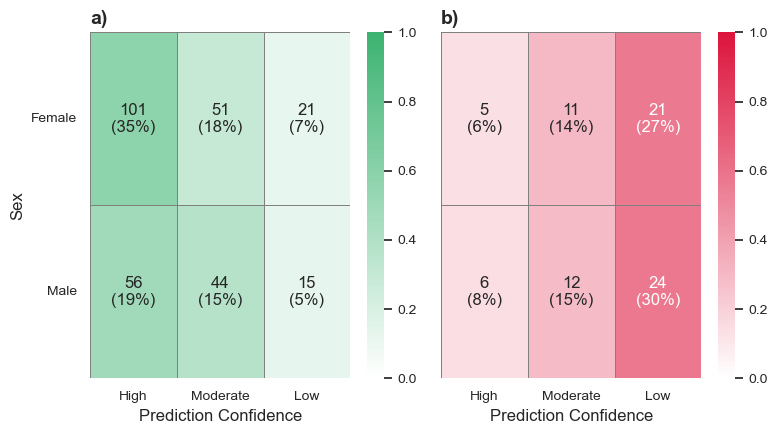

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


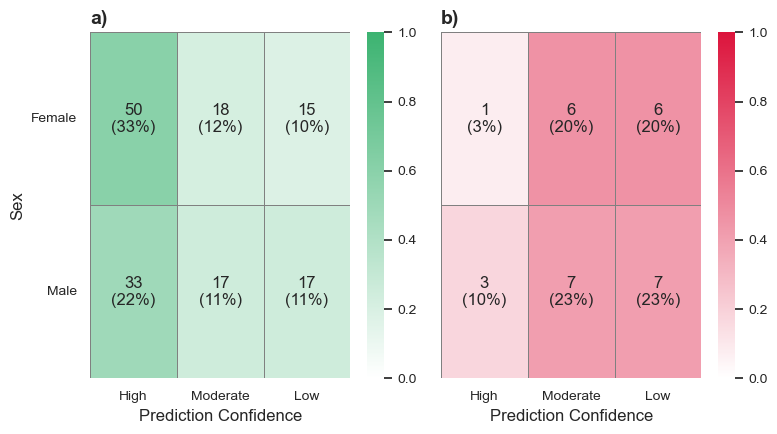

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für neg_log_loss gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\Sex_plots\neg_log_loss

📊 Running prediction & plots for metric: f1


C:\Users\Frede\AppData\Local\Temp\ipykernel_8784\1749748555.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


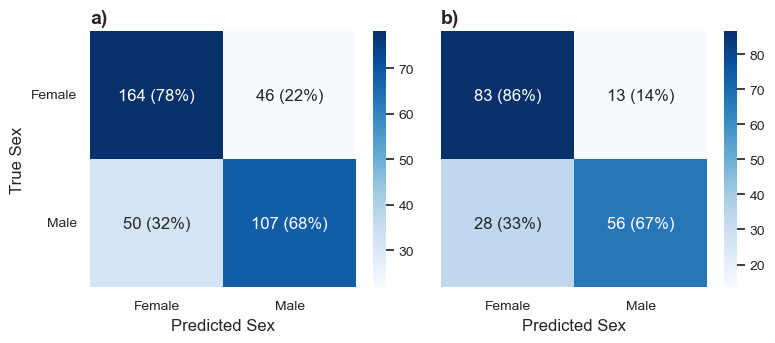

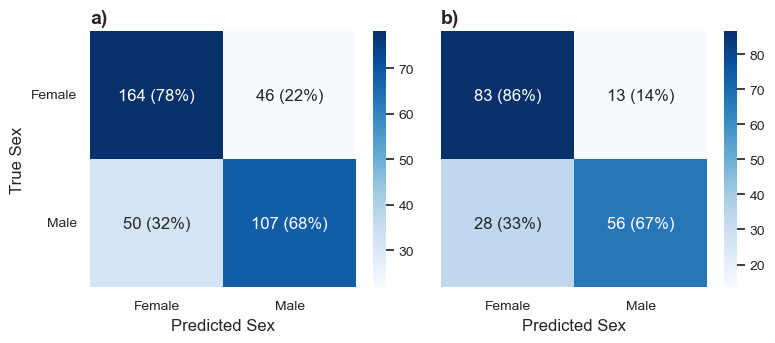

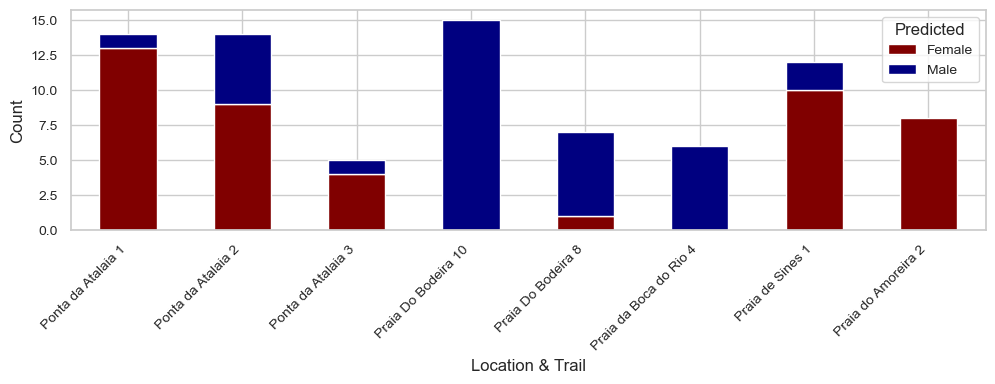

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

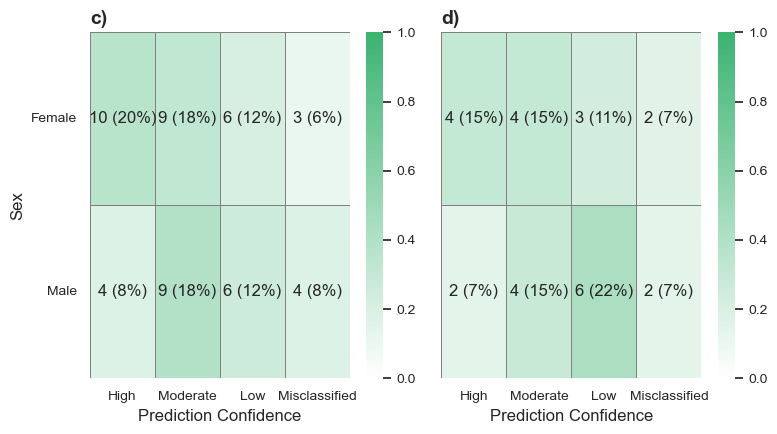

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

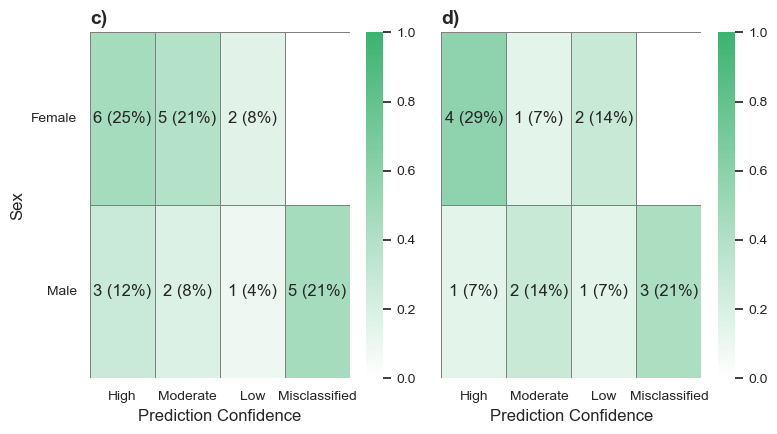

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


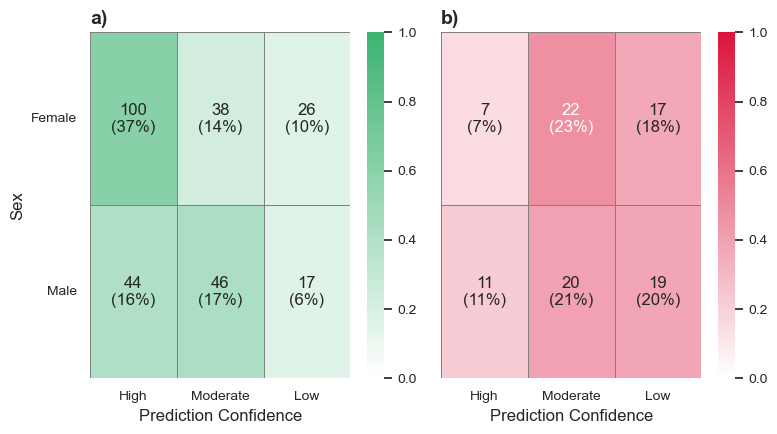

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


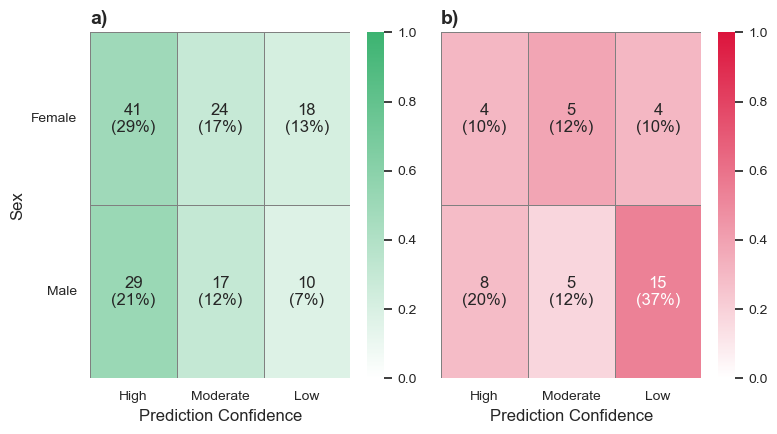

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für f1 gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\Sex_plots\f1

📊 Running prediction & plots for metric: precision


C:\Users\Frede\AppData\Local\Temp\ipykernel_8784\1749748555.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


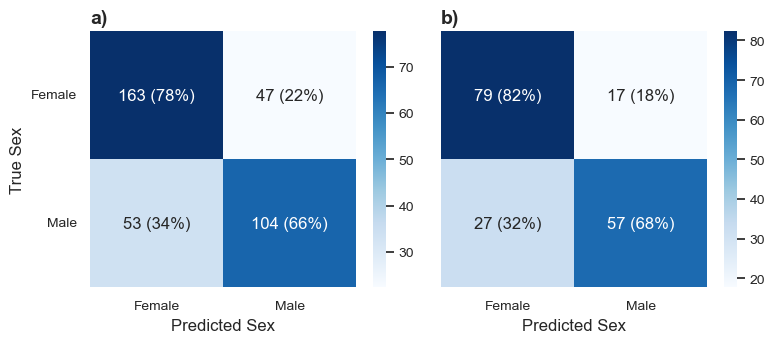

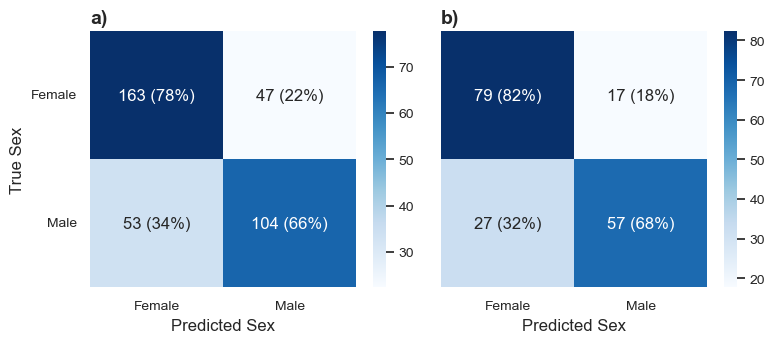

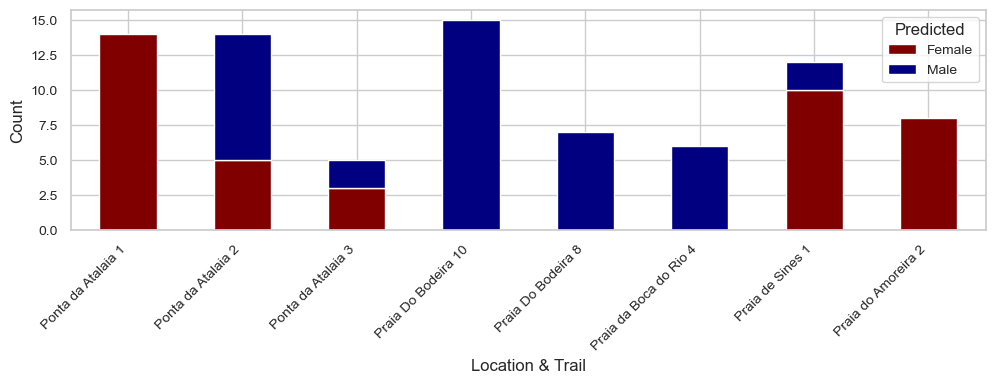

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

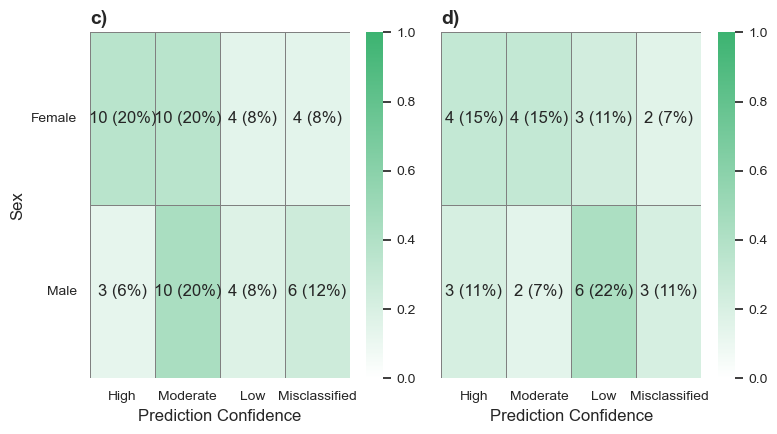

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

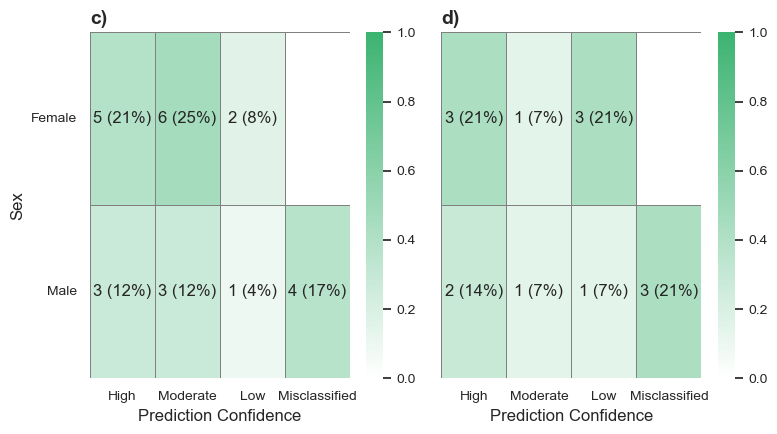

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


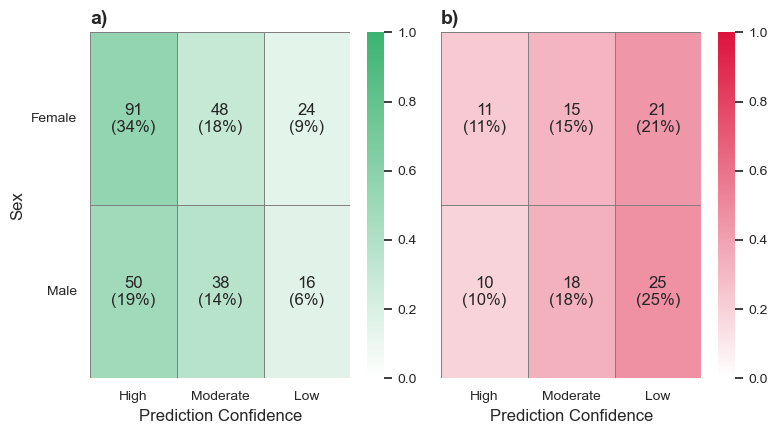

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


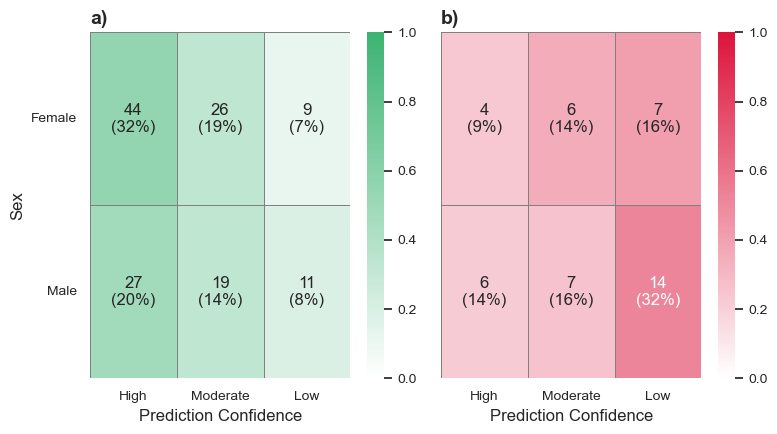

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für precision gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\Sex_plots\precision

📊 Running prediction & plots for metric: recall


C:\Users\Frede\AppData\Local\Temp\ipykernel_8784\1749748555.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


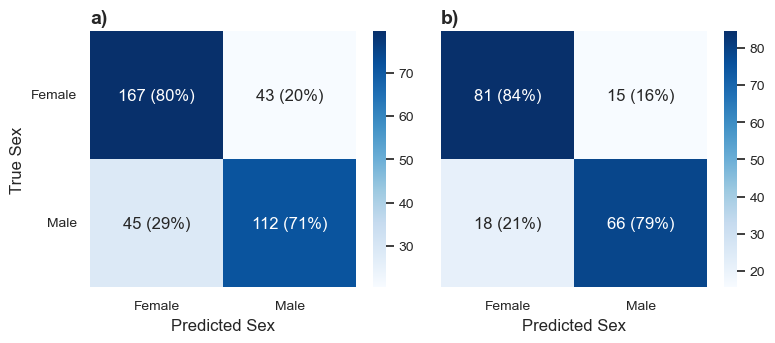

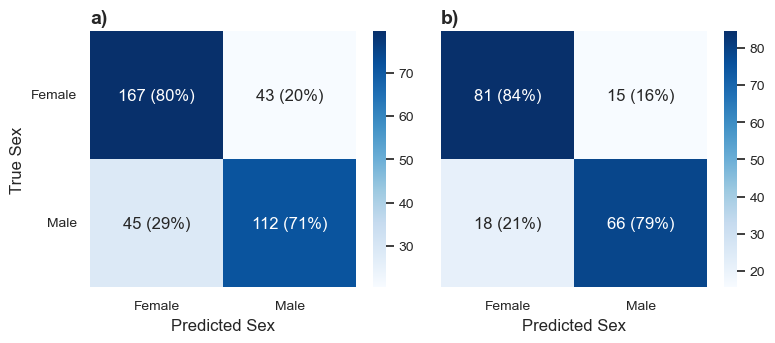

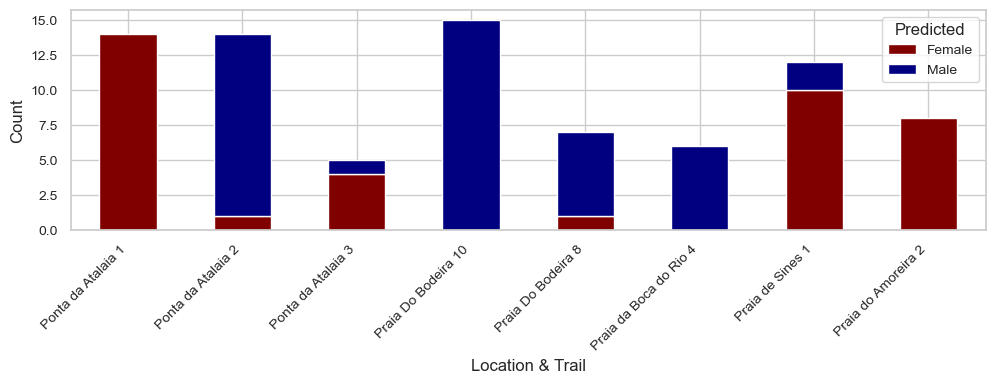

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

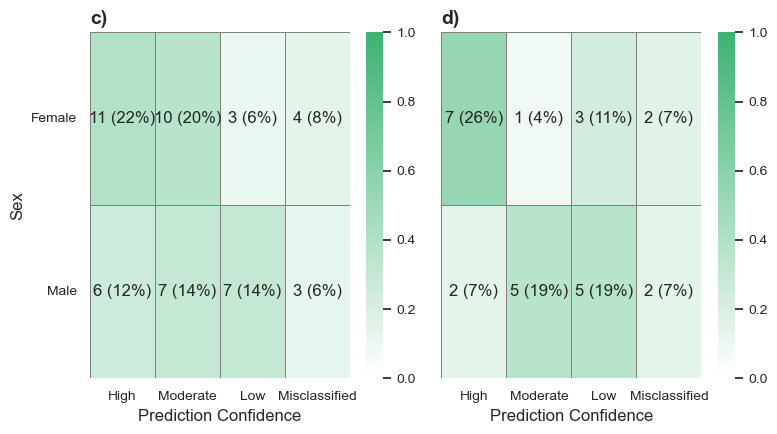

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

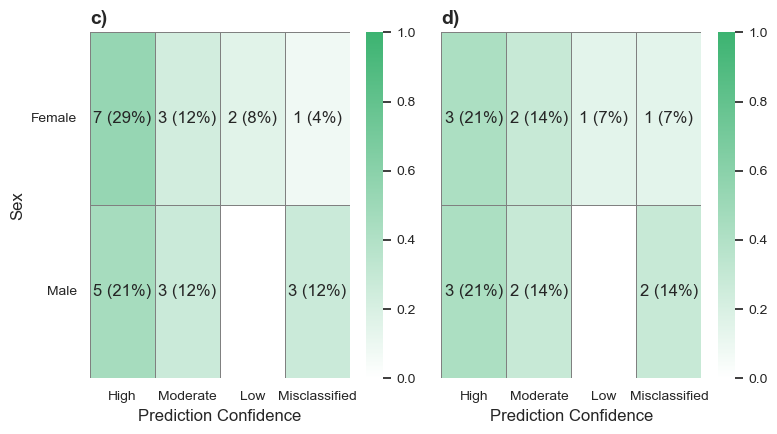

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


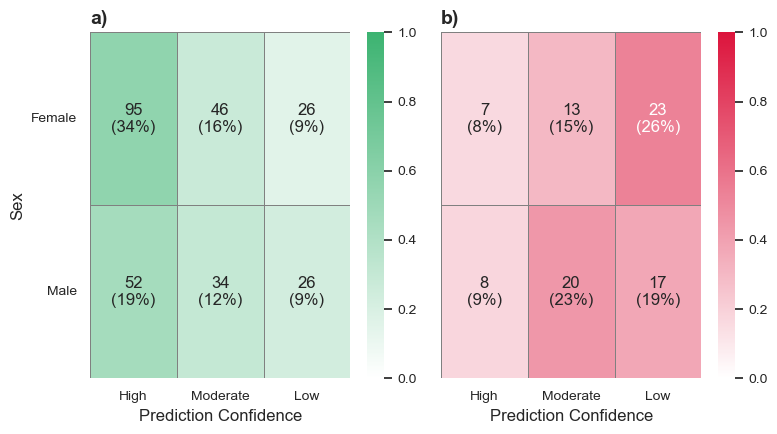

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


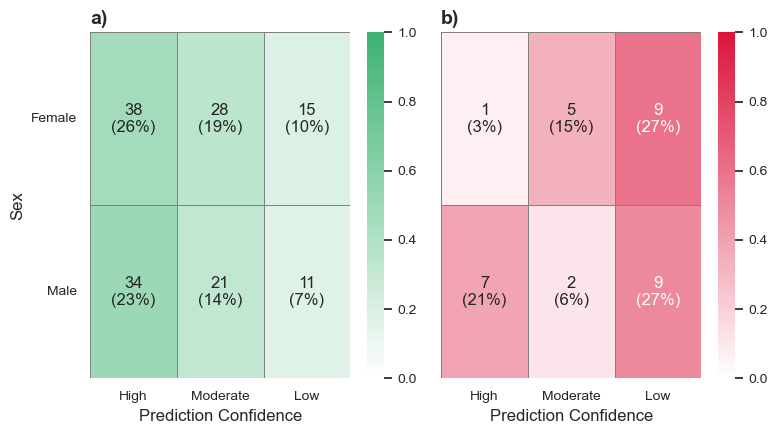

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für recall gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\Sex_plots\recall

📊 Running prediction & plots for metric: roc_auc


C:\Users\Frede\AppData\Local\Temp\ipykernel_8784\1749748555.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


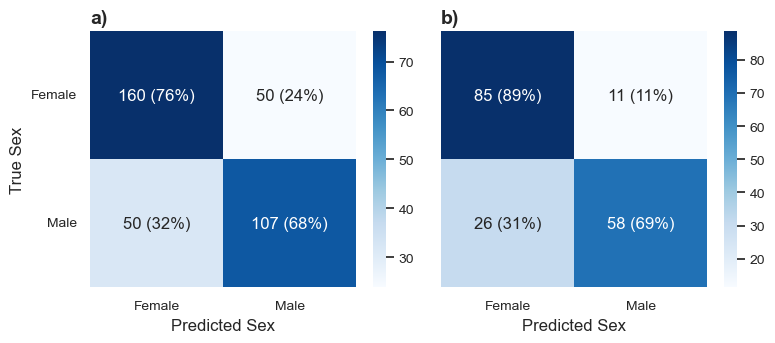

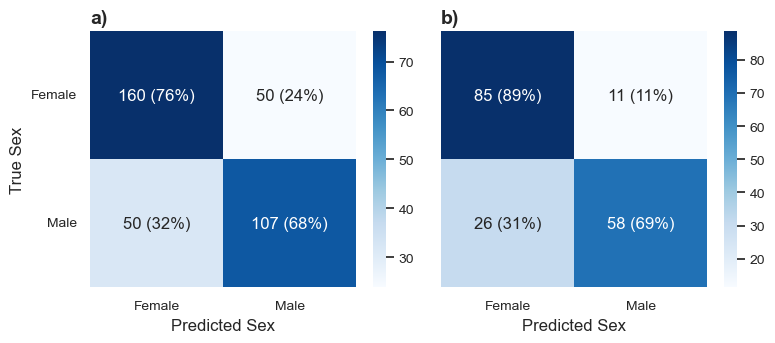

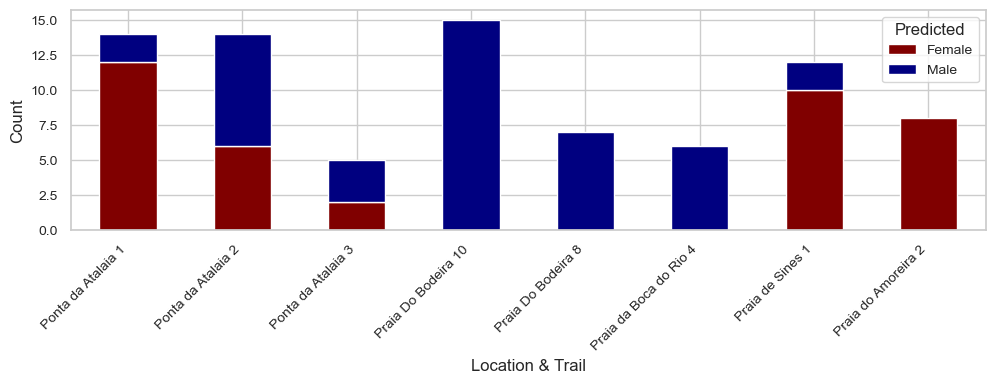

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

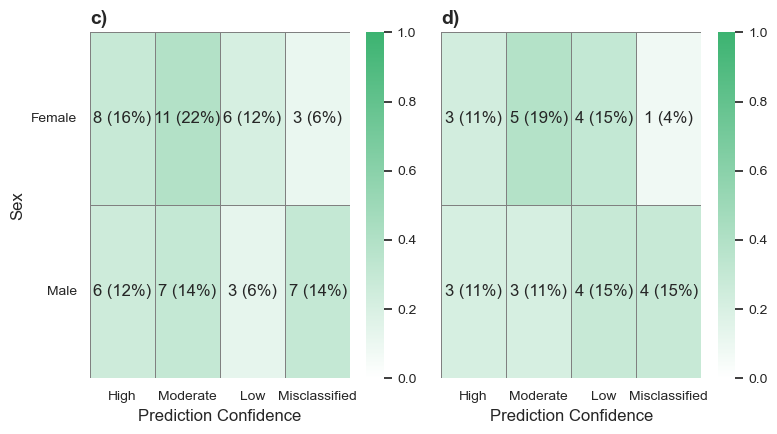

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:524: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

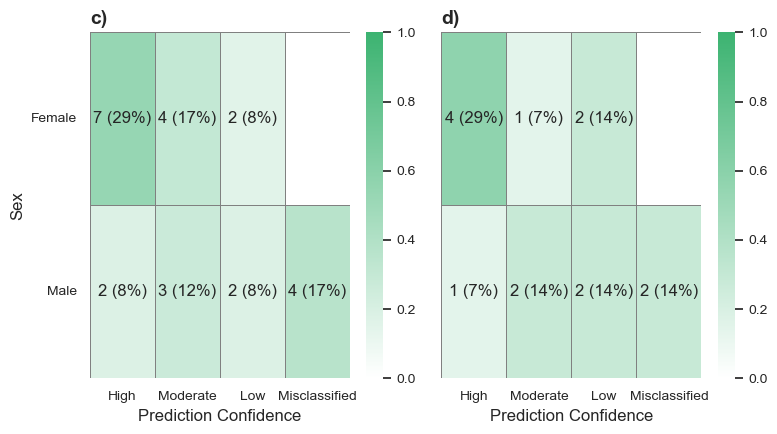

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


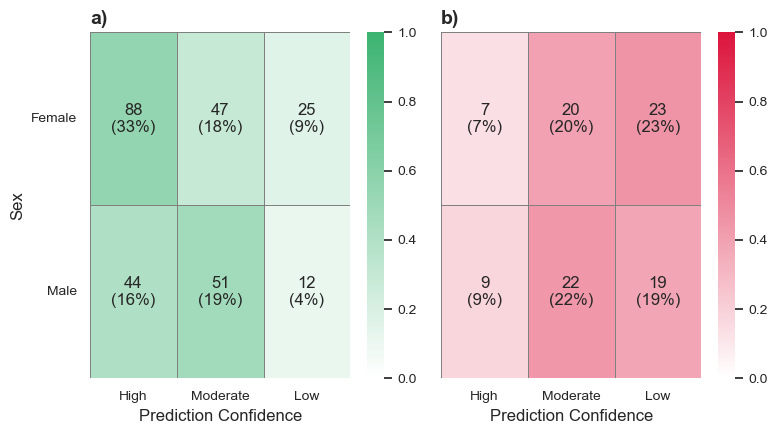

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:693: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


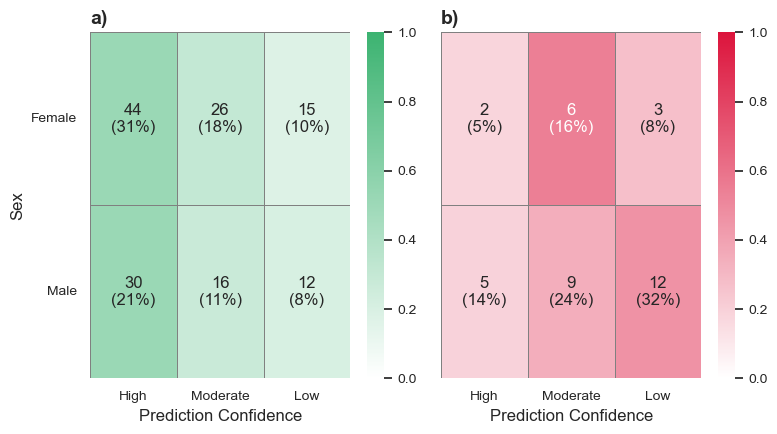

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für roc_auc gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\Sex_plots\roc_auc


In [ ]:
# === Imports ===
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import importlib
from FIT_python.soft_config import SOFT_CONFIG

from FIT_python import config
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    predict_all,
    plot_confusion_and_inference,
    plot_quality_grouped,
    plot_quality_heatmaps,
    plot_individual_probabilities,
    plot_confusion,
)

# === Parameter ===
DEFAULT_SPECIES = "eurasian_otter"
SCORING_METRICS = list(SOFT_CONFIG["pipeline_sex"]["scoring"].keys())
BASE_DIR = config.EXPERIMENT_ROOT
SEX_DIR = BASE_DIR / "Sex_plots"
SEX_DIR.mkdir(parents=True, exist_ok=True)

sex_mapping = {"F": 0, "M": 1, "f": 0, "m": 1}

# === Funktion für Histogrammplots ===
def plot_histogram_per_model(df, metric_key, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    df_plot = df.copy()
    df_plot["true_label"] = df_plot["sex"].replace(sex_mapping)
    df_plot["split_label"] = df_plot["__split__"].replace({"train": "Train (CV)", "test": "Test"})

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for i, split in enumerate(["train", "test"]):
        df_sub = df_plot[df_plot["__split__"] == split]
        if df_sub.empty:
            continue
        sns.histplot(
            data=df_sub,
            x="pred_sex",
            hue="individual_id",
            multiple="stack",
            bins=10,
            ax=axes[i],
            palette="Set2",
            legend=False
        )
        axes[i].set_title(f"{split.capitalize()} Set – Prediction Distribution")
        axes[i].set_ylabel("Count")
    axes[1].set_xlabel("Predicted Sex (0=F, 1=M)")
    fig.suptitle(f"Prediction Histogram by Individual – {metric_key}", fontsize=14)
    plt.tight_layout()
    fig.savefig(out_dir / f"prediction_histogram_{metric_key}.png")
    plt.close()


# === Hauptloop über alle Scoring-Metriken ===
for metric_key in SCORING_METRICS:
    print(f"\n📊 Running prediction & plots for metric: {metric_key}")
    df_all = predict_all(
        species=DEFAULT_SPECIES,
        metric_key=metric_key,
        prefer_generic=False,
        include_inference=True,
        reuse_csv=False,
        use_cv_train_predictions=True
    )

    # Mapping für Vorhersage vereinheitlichen
    if "pred_sex" in df_all.columns:
        df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)

    out_dir = SEX_DIR / metric_key
    out_dir.mkdir(parents=True, exist_ok=True)

    # Plots
    plot_confusion(df_all)
    plot_confusion_and_inference(df_all)
    plot_quality_grouped(df_all)
    plot_quality_heatmaps(df_all)
    plot_individual_probabilities(df_all, out_dir=out_dir)

    # Histogramm zusätzlich
    plot_histogram_per_model(df_all, metric_key, out_dir)

    print(f"✅ Ergebnisse für {metric_key} gespeichert in {out_dir}")


In [5]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib
import time  # <- neu

from FIT_python.pipeline_individual_id.simple_baseline import run_fold_cv, get_feature_cols
from FIT_python.pipeline_individual_id.generate_trails_and_trailpairs import generate_pairwise_comparisons_from_df
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_sex.sex_predict_and_visualisation import predict_all
from FIT_python.soft_config import SOFT_CONFIG

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Splits aus config ---
base_dir = cfg.SPLITS_DIR
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

# --- Output-Verzeichnis für Individual ID Ergebnisse ---
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)

results = {}
k_range = range(14, 18)
selection_methods = ["lasso", "random_forest", "forward"]
sex_flags = [True] #, True

for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    print(f"\n##### {species} #####")

    train_path = sp_dir / "train.parquet"
    test_path = sp_dir / "test.parquet"
    if not train_path.exists() or not test_path.exists():
        print(f"⚠️ Überspringe {species}, da train/test fehlt.")
        continue

    df_train = pd.read_parquet(train_path)
    df_test = pd.read_parquet(test_path)
    feature_cols = get_feature_cols(df_train)

    out_dir = out_base_dir / species
    out_dir.mkdir(parents=True, exist_ok=True)

    # Sammlung aller Paarvergleiche über CV + Test für dieses Species
    master_pairs = []

    # Sex‑Vorhersagen (OOF für Train, voll trainiertes Modell für Test)
    sex_preds = predict_all(species, reuse_csv=True)

    for fs in selection_methods:
        for k in k_range:
            for use_sex in sex_flags:
                start_time = time.perf_counter()  # --- Zeiterfassung ---
                tag = f"{fs}_k{k}_{'sex' if use_sex else 'morph'}"
                run_dir = out_dir / tag
                run_dir.mkdir(parents=True, exist_ok=True)

                # --- 1) CV ---
                cv_dir = run_dir / "cv_results"
                cv_dir.mkdir(parents=True, exist_ok=True)
                summary_cv = run_fold_cv(
                    df_train,
                    feature_cols,
                    sex_predictions=sex_preds,
                    fold_col="Fold",
                    out_dir=cv_dir,
                    selection_method=fs,
                    k_features=k,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    reuse_summary=True,
                )
                print(f"CV fertig: {species} – {tag}")

                # CV-Paare laden und annotieren
                cv_pairs_fp = cv_dir / "all_folds.csv"
                if cv_pairs_fp.exists():
                    cv_pairs = pd.read_csv(cv_pairs_fp)
                    cv_pairs["origin"] = "cv"
                    cv_pairs["tag"] = tag
                    master_pairs.append(cv_pairs)

                # --- 2) Test‑Paare ---
                pairs_dir = run_dir / "test_pairs"
                pairs_dir.mkdir(parents=True, exist_ok=True)

                comps_test, _ = generate_pairwise_comparisons_from_df(
                    df_test, strategy="select", evaluation=True, subsample=False
                )

                SOFT_CONFIG["pipeline_individual_id"]["pairwise_defaults"]["k_features"] = k
                res_df = DistanceBaseline.run(
                    train_df=df_train,
                    val_comparisons=comps_test,
                    val_df=df_test,
                    feature_cols=feature_cols,
                    selection_method=fs,
                    reducers=["lda"],
                    n_components=2,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    n_jobs=-1,
                )
                res_df.to_csv(pairs_dir / f"{species}_pairs.csv", index=False)
                print(f"Test‑Paare gespeichert: {pairs_dir / f'{species}_pairs.csv'}")

                runtime_s = time.perf_counter() - start_time  # --- Laufzeit berechnen ---

                # Test-Paare annotieren
                test_pairs = res_df.copy()
                test_pairs["origin"] = "test"
                test_pairs["tag"] = tag
                test_pairs["runtime_s"] = runtime_s
                if cv_pairs_fp.exists():
                    cv_pairs["runtime_s"] = runtime_s
                master_pairs.append(test_pairs)

                results.setdefault(species, []).append({
                    "tag": tag,
                    "cv_summary": summary_cv,
                    "test_pairs": res_df,
                    "runtime_s": runtime_s,
                })

    # --- Master-Tabelle für dieses Species ---
    if master_pairs:
        master_df = pd.concat(master_pairs, ignore_index=True)
        master_df.to_csv(out_dir / f"{species}_master_pairs.csv", index=False)

print("\n✅ Analysen für alle Spezies abgeschlossen.")


✅ Using base_dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\data\splits
✅ Saving results to: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\individual_id

##### amur_tiger #####


FileNotFoundError: Sex model file not found: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\results_data\panthera_tigris_altaica\models\roc_auc\panthera_tigris_altaica.joblib

#Basline FIT modelbassiert

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)



# --- Pfade aus config ---
base_dir = cfg.EXPERIMENT_ROOT
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)


# --- Hilfsfunktionen ---
def build_pipeline(method, dist_cols):
    if method == "SelectKBest":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(mutual_info_classif)),
            ("model", LinearDiscriminantAnalysis())
        ]), [
            {
                "select__k": list(range(1, len(dist_cols)+1)),
                "model__solver": ["svd"],
                "model__shrinkage": [None]
            },
            {
                "select__k": list(range(1, len(dist_cols)+1)),
                "model__solver": ["lsqr"],
                "model__shrinkage": [None, 0.1, 0.5, 0.9]
            }
        ]
    elif method == "PCA98":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.98)),
            ("model", LinearDiscriminantAnalysis())
        ]), [
            {
                "model__solver": ["svd"],
                "model__shrinkage": [None]
            },
            {
                "model__solver": ["lsqr"],
                "model__shrinkage": [None, 0.1, 0.5, 0.9]
            }
        ]
    else:
        raise ValueError(f"Unbekannte Methode: {method}")

# --- Hauptloop ---
for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    print(f"\n=== LDA Modellierung für {species} ===")

    cv_csv = out_base_dir / species / "cv_results" / "all_folds.csv"
    tp_csv = out_base_dir / species / "test_pairs" / f"{species}_pairs.csv"
    if not (cv_csv.exists() and tp_csv.exists()):
        print(f"⚠️ Daten fehlen für {species}, überspringe.")
        continue

    df_cv = pd.read_csv(cv_csv)
    df_tp = pd.read_csv(tp_csv)

    df_cv = df_cv[~(df_cv["trail_a_id"].str.strip().eq("unknown") |
                    df_cv["trail_b_id"].str.strip().eq("unknown"))]
    df_tp = df_tp[~(df_tp["trail_a_id"].str.strip().eq("unknown") |
                    df_tp["trail_b_id"].str.strip().eq("unknown"))]

    dist_cols = [c for c in df_cv.columns if c.startswith(("dist_", "mean_", "median_", "min_", "max_"))]
    if not dist_cols:
        print(f"⚠️ Keine Distanz-Features für {species}, überspringe.")
        continue

    df_cv = df_cv.dropna(subset=dist_cols)
    df_tp = df_tp.dropna(subset=dist_cols)

    X_cv = df_cv[dist_cols].to_numpy()
    y_cv = df_cv["same_individual"].map({True: 1, False: 0}).to_numpy()
    ps   = PredefinedSplit(test_fold=df_cv["fold"].to_numpy())

    X_test = df_tp[dist_cols].to_numpy()
    y_test = df_tp["same_individual"].map({True: 1, False: 0}).to_numpy()

    results = []

    for method in ["SelectKBest", "PCA98"]:
        pipe, param_grid = build_pipeline(method, dist_cols)
        gs = GridSearchCV(pipe, param_grid, scoring="balanced_accuracy", cv=ps, refit=True, n_jobs=-1, verbose=0)
        gs.fit(X_cv, y_cv)

        model = gs.best_estimator_
        cv_score = balanced_accuracy_score(y_cv, model.predict(X_cv))
        test_score = balanced_accuracy_score(y_test, model.predict(X_test))

        result = {
            "species": species,
            "method": method,
            "cv_bal_acc": round(cv_score, 3),
            "test_bal_acc": round(test_score, 3)
        }

        if method == "SelectKBest":
            k = model.named_steps["select"].k
            feats = np.array(dist_cols)[model.named_steps["select"].get_support()].tolist()
            result["best_k"] = k
            result["selected_features"] = ";".join(feats)
        elif method == "PCA98":
            result["pca_n_components"] = model.named_steps["pca"].n_components_

        results.append(result)

    # Speichern in gemeinsamer Datei pro Spezies
    df_out = pd.DataFrame(results)
    out_fp = out_base_dir / species / "lda_selectk_vs_pca98.csv"
    df_out.to_csv(out_fp, index=False)

    # Print
    print(f"✅ {species} gespeichert: {out_fp.name}")
    for res in results:
        print(f"   {res['method']}: Test = {res['test_bal_acc']:.3f}, CV = {res['cv_bal_acc']:.3f}")
        if res["method"] == "SelectKBest":
            print(f"     best_k = {res['best_k']}, Features = {res['selected_features']}")
        else:
            print(f"     PCA Components = {res['pca_n_components']}")


✅ Using base_dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2
✅ Saving results to: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast_2\individual_id

=== LDA Modellierung für benchmark ===
⚠️ Daten fehlen für benchmark, überspringe.

=== LDA Modellierung für data ===
⚠️ Daten fehlen für data, überspringe.

=== LDA Modellierung für figures ===
⚠️ Daten fehlen für figures, überspringe.

=== LDA Modellierung für individual_id ===
⚠️ Daten fehlen für individual_id, überspringe.

=== LDA Modellierung für results_data ===
⚠️ Daten fehlen für results_data, überspringe.

=== LDA Modellierung für Sex_plots ===
⚠️ Daten fehlen für Sex_plots, überspringe.

=== LDA Modellierung für split_fig ===
⚠️ Daten fehlen für split_fig, überspringe.


BAseline ERD 

Grid serach mit novelities

Benchmark best Individual Classification model for all species 

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Pfade aus Config ---
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Saving results to:", out_base_dir)

# --- Iteration über Spezies ---
for sp_dir in sorted(out_base_dir.iterdir()):
    master_fp = sp_dir / f"{sp_dir.name}_master_pairs.csv"
    if not master_fp.exists():
        continue

    df_master = pd.read_csv(master_fp)
    df_master = df_master[~(df_master["trail_a_id"].str.strip().eq("unknown") |
                             df_master["trail_b_id"].str.strip().eq("unknown"))]

    dist_cols = [c for c in df_master.columns if c.startswith(("dist_", "mean_", "median_", "min_", "max_"))]

    for tag, df_tag in df_master.groupby("tag"):
        print(f"\n=== {sp_dir.name} – {tag} ===")

        df_cv = df_tag[df_tag["origin"] == "cv"].dropna(subset=dist_cols)
        df_tp = df_tag[df_tag["origin"] == "test"].dropna(subset=dist_cols)
        if df_cv.empty or df_tp.empty:
            print("⚠️ Daten unvollständig, überspringe.")
            continue

        X_cv = df_cv[dist_cols].to_numpy()
        y_cv = df_cv["same_individual"].map({True: 1, False: 0}).to_numpy()
        ps = PredefinedSplit(test_fold=df_cv["fold"].to_numpy())

        X_test = df_tp[dist_cols].to_numpy()
        y_test = df_tp["same_individual"].map({True: 1, False: 0}).to_numpy()

        results = []

        for method in ["SelectKBest", "PCA98"]:
            if method == "SelectKBest":
                pipe = Pipeline([
                    ("scaler", StandardScaler()),
                    ("select", SelectKBest(mutual_info_classif)),
                    ("model", LinearDiscriminantAnalysis())
                ])
                param_grid = [
                    {
                        "select__k": list(range(1, len(dist_cols) + 1)),
                        "model__solver": ["svd"],
                        "model__shrinkage": [None]
                    },
                    {
                        "select__k": list(range(1, len(dist_cols) + 1)),
                        "model__solver": ["lsqr"],
                        "model__shrinkage": [None, 0.1, 0.5, 0.9]
                    }
                ]
            else:
                pipe = Pipeline([
                    ("scaler", StandardScaler()),
                    ("pca", PCA(n_components=0.98)),
                    ("model", LinearDiscriminantAnalysis())
                ])
                param_grid = [
                    {
                        "model__solver": ["svd"],
                        "model__shrinkage": [None]
                    },
                    {
                        "model__solver": ["lsqr"],
                        "model__shrinkage": [None, 0.1, 0.5, 0.9]
                    }
                ]

            gs = GridSearchCV(pipe, param_grid, scoring="balanced_accuracy", cv=ps, refit=True, n_jobs=-1, verbose=0)
            gs.fit(X_cv, y_cv)

            y_cv_pred = gs.predict(X_cv)
            y_test_pred = gs.predict(X_test)

            acc_cv = balanced_accuracy_score(y_cv, y_cv_pred)
            acc_test = balanced_accuracy_score(y_test, y_test_pred)
            cm_cv = confusion_matrix(y_cv, y_cv_pred, labels=[1, 0])
            cm_test = confusion_matrix(y_test, y_test_pred, labels=[1, 0])

            result = {
                "species": sp_dir.name,
                "tag": tag,
                "method": method,
                "cv_bal_acc": acc_cv,
                "test_bal_acc": acc_test,
                "cv_true_same_pred_same": int(cm_cv[0, 0]),
                "cv_true_same_pred_diff": int(cm_cv[0, 1]),
                "cv_true_diff_pred_same": int(cm_cv[1, 0]),
                "cv_true_diff_pred_diff": int(cm_cv[1, 1]),
                "test_true_same_pred_same": int(cm_test[0, 0]),
                "test_true_same_pred_diff": int(cm_test[0, 1]),
                "test_true_diff_pred_same": int(cm_test[1, 0]),
                "test_true_diff_pred_diff": int(cm_test[1, 1])
            }

            if method == "SelectKBest":
                sel = gs.best_estimator_.named_steps["select"]
                selected = np.array(dist_cols)[sel.get_support()].tolist()
                result["best_k"] = sel.k
                result["selected_features"] = ";".join(selected)
            else:
                result["pca_n_components"] = gs.best_estimator_.named_steps["pca"].n_components_

            results.append(result)

        out_dir = sp_dir / tag
        out_dir.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(results).to_csv(out_dir / "distance_lda_selectk_vs_pca.csv", index=False)


# --- Benchmark zusammenfassen ---
benchmark = []
for summary_csv in out_base_dir.rglob("distance_lda_selectk_vs_pca.csv"):
    benchmark.append(pd.read_csv(summary_csv))

benchmark_df = pd.concat(benchmark, ignore_index=True).sort_values(["species", "tag", "method"])
benchmark_df.to_csv(out_base_dir / "benchmark_lda_selectk_vs_pca.csv", index=False)

print("\n=== Gesamt-Benchmark ===")
print(benchmark_df)


Benchmark improvements erd pipliens

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

from FIT_python.pipeline_individual_id.population_estimation import (
    cluster_population,
    compute_erd,
)
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

# Distanz-Metriken
base_metrics = [
    "euclidean", "manhattan", "cosine",
    "chebyshev", "canberra", "braycurtis"
]

cutoff_range = np.arange(0.4, 4.2, 0.1)


def evaluate_clusters(D, true_labels, cutoff):
    """Clustern und Cluster-Metriken berechnen."""
    condensed = squareform(D.to_numpy(), checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")

    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    return cluster_labels, h, c, v


def process_combination(species, tag, dist_col, prep, df_cv, df_test):
    bench_key = {
        "species": species,
        "tag": tag,
        "dist_col": dist_col,
        "preprocessing": prep,
    }

    try:
        # ---------------- CV: Cutoff-Optimierung ----------------
        recs = []
        for fold_id, fold_df in df_cv.groupby("fold"):
            trails = sorted({*fold_df["trail_a_id"], *fold_df["trail_b_id"]})
            D = pd.DataFrame(np.nan, index=trails, columns=trails)
            for a, b, d in zip(
                fold_df["trail_a_id"], fold_df["trail_b_id"], fold_df[dist_col]
            ):
                D.at[a, b] = D.at[b, a] = d
            np.fill_diagonal(D.values, 0.0)
            D = D.fillna(D.values.max())

            if prep == "minmax":
                D[:] = MinMaxScaler().fit_transform(D)

            # Wahre Labels für Trails
            label_map = {}
            label_map.update(fold_df.set_index("trail_a_id")["ind_a"].to_dict())
            label_map.update(fold_df.set_index("trail_b_id")["ind_b"].to_dict())
            true_labels = [str(label_map[t]) for t in trails]
            true_n = len(np.unique(true_labels))

            for cutoff in cutoff_range:
                cluster_labels, h, c, v = evaluate_clusters(D, true_labels, cutoff)
                pred_n = len(np.unique(cluster_labels))
                erd = compute_erd(pred_n, true_n)

                score = alpha * (1 - erd) + (1 - alpha) * v  # Gewichtung hier!

                recs.append({
                    "species": species,
                    "tag": tag,
                    "dist_col": dist_col,
                    "preprocessing": prep,
                    "fold": fold_id,
                    "cutoff": cutoff,
                    "erd": erd,
                    "pred_n": pred_n,
                    "true_n": true_n,
                    "homogeneity": h,
                    "completeness": c,
                    "v_measure": v,
                    "score": score
                })


        cut_df = pd.DataFrame(recs)
        mean_scores = cut_df.groupby("cutoff")[["erd","homogeneity","completeness","v_measure"]].mean().reset_index()
        best = mean_scores.loc[mean_scores["erd"].idxmin()]
        best_cutoff = float(best["cutoff"])
        mean_erd_cv = float(best["erd"])
        mean_h_cv   = float(best["homogeneity"])
        mean_c_cv   = float(best["completeness"])
        mean_v_cv   = float(best["v_measure"])

        # ---------------- Test-Set ----------------
        if not df_test.empty:
            trails = sorted({*df_test["trail_a_id"], *df_test["trail_b_id"]})
            Dtest = pd.DataFrame(np.nan, index=trails, columns=trails)
            for a, b, d in zip(
                df_test["trail_a_id"], df_test["trail_b_id"], df_test[dist_col]
            ):
                Dtest.at[a, b] = Dtest.at[b, a] = d
            np.fill_diagonal(Dtest.values, 0.0)
            Dtest = Dtest.fillna(Dtest.values.max())

            if prep == "minmax":
                Dtest[:] = MinMaxScaler().fit_transform(Dtest)

            label_map_test = {}
            label_map_test.update(df_test.set_index("trail_a_id")["ind_a"].to_dict())
            label_map_test.update(df_test.set_index("trail_b_id")["ind_b"].to_dict())
            true_labels_test = [str(label_map_test[t]) for t in trails]
            true_n_t = len(np.unique(true_labels_test))

            cluster_labels, h_t, c_t, v_t = evaluate_clusters(Dtest, true_labels_test, best_cutoff)
            pred_n_t = len(np.unique(cluster_labels))
            erd_test = compute_erd(pred_n_t, true_n_t)
        else:
            pred_n_t = true_n_t = erd_test = h_t = c_t = v_t = np.nan

        return {
            **bench_key,
            "cv_cutoff": best_cutoff,
            "cv_mean_erd": mean_erd_cv,
            "cv_mean_homogeneity": mean_h_cv,
            "cv_mean_completeness": mean_c_cv,
            "cv_mean_v_measure": mean_v_cv,
            "test_pred_n": pred_n_t,
            "test_true_n": true_n_t,
            "test_erd": erd_test,
            "test_homogeneity": h_t,
            "test_completeness": c_t,
            "test_v_measure": v_t,
            "status": "ok",
            "cut_df": cut_df
        }

    except Exception as e:
        return {**bench_key, "status": f"skipped: {e}"}


all_tasks = []
# Optionaler Tag-Filter:
# wanted_tags = ["forward_k16_morph", "lasso_k13_sex", "lasso_k16_sex", "lasso_k19_sex"]

for sp_dir in sorted(out_base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name

    master_fp = sp_dir / f"{species}_master_pairs.csv"
    if not master_fp.exists():
        continue

    df_master = pd.read_csv(master_fp)
    df_master = df_master[
        ~(df_master["trail_a_id"].str.strip().eq("unknown") |
          df_master["trail_b_id"].str.strip().eq("unknown"))
    ]

    between_cols = [c for c in df_master.columns if "between" in c]
    metrics = [f"dist_{m}" for m in base_metrics] + between_cols

    for tag, df_tag in df_master.groupby("tag"):
        # Filter nur aktivieren, wenn wanted_tags gesetzt ist
        # if tag not in wanted_tags:
        #     continue

        df_cv = df_tag[df_tag["origin"] == "cv"]
        df_test = df_tag[df_tag["origin"] == "test"]

        for dist_col in metrics:
            if dist_col not in df_tag.columns:
                continue
            for prep in ["raw", "minmax"]:
                all_tasks.append((species, tag, dist_col, prep, df_cv, df_test))

print(f"Gesammelte Tasks: {len(all_tasks)}")


print(f"Starte {len(all_tasks)} Kombinationen …")
results = Parallel(n_jobs=-1)(
    delayed(process_combination)(*task) for task in tqdm(all_tasks)
)

# Speichern
records, cutoff_records = [], []
for res in results:
    if res["status"] == "ok":
        cutoff_records.append(res.pop("cut_df"))
    records.append(res)

benchmark_df = pd.DataFrame(records)
benchmark_df.to_csv(out_base_dir / "benchmark_full_distances_with_metrics.csv", index=False)

if cutoff_records:
    cutoff_df = pd.concat(cutoff_records, ignore_index=True)
    cutoff_df.to_csv(out_base_dir / "benchmark_cutoff_curves_with_metrics.csv", index=False)

print("=== Benchmark Summary ===")
display(benchmark_df)
display(cutoff_df)

In [ ]:
import pandas as pd
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"

# Cutoff-Kurven laden
cutoff_fp = out_base_dir / "benchmark_cutoff_curves_with_metrics.csv"
cutoff_df = pd.read_csv(cutoff_fp)

# Score berechnen (gleichgewichtet: α = 0.5)
alpha = 0.5
cutoff_df["cv_best_score"] = (
    alpha * (1 - cutoff_df["erd"]) + 
    (1 - alpha) * cutoff_df["v_measure"]
)

# Score pro Cutoff foldübergreifend mitteln
mean_scores = (
    cutoff_df.groupby(["species","tag","cutoff","dist_col","preprocessing"])
    .agg({
        "erd": "mean",
        "homogeneity": "mean",
        "completeness": "mean",
        "v_measure": "mean",
        "cv_best_score": "mean"
    })
    .reset_index()
)

# Besten Cutoff pro Species + Tag bestimmen
best_cutoffs = (
    mean_scores.sort_values(["species","tag","cv_best_score"], ascending=[True, True, False])
    .groupby(["species","tag","cutoff","dist_col","preprocessing"])
    .head(1)
    .reset_index(drop=True)
)

print("=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===")
display(best_cutoffs[[
    "species","tag","cutoff","erd","homogeneity","completeness","v_measure","cv_best_score"
]])

# Ergebnisse speichern
out_fp = out_base_dir / "best_cutoffs_combined_score_mean.csv"
best_cutoffs.to_csv(out_fp, index=False)
print(f"\n✅ Ergebnisse gespeichert unter: {out_fp}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"

# Cutoff-Kurven laden
cutoff_fp = out_base_dir / "benchmark_cutoff_curves_with_metrics.csv"
cutoff_df = pd.read_csv(cutoff_fp)

# Score berechnen (gleichgewichtet: α = 0.5)
alpha = 0.5
cutoff_df["cv_best_score"] = (
    alpha * (1 - cutoff_df["erd"]) + 
    (1 - alpha) * cutoff_df["v_measure"]
)

# Score pro Cutoff foldübergreifend mitteln
mean_scores = (
    cutoff_df.groupby(["species","tag","dist_col","preprocessing","cutoff"])
    .agg({
        "erd": "mean",
        "homogeneity": "mean",
        "completeness": "mean",
        "v_measure": "mean",
        "cv_best_score": "mean"
    })
    .reset_index()
)

# Besten Cutoff pro Pipeline bestimmen
best_cutoffs = (
    mean_scores.sort_values(["species","tag","dist_col","preprocessing","cv_best_score"],
                            ascending=[True, True, True, True, False])
    .groupby(["species","tag","dist_col","preprocessing"])
    .head(1)
    .reset_index(drop=True)
)

print("=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===")
display(best_cutoffs[[
    "species","tag","dist_col","preprocessing","cutoff",
    "erd","homogeneity","completeness","v_measure","cv_best_score"
]])

# Ergebnisse speichern
out_fp = out_base_dir / "best_cutoffs_combined_score_mean.csv"
best_cutoffs.to_csv(out_fp, index=False)
print(f"\n✅ Ergebnisse gespeichert unter: {out_fp}")

# --- Plot für die beste Pipeline ---
# Beste Pipeline wählen
best_pipeline = best_cutoffs.sort_values("cv_best_score", ascending=False).iloc[0]
species = best_pipeline["species"]
tag = best_pipeline["tag"]
dist_col = best_pipeline["dist_col"]
prep = best_pipeline["preprocessing"]

print(f"\n📊 Beste Pipeline: {species}, {tag}, {dist_col}, {prep}")

df_plot = cutoff_df.query(
    "species == @species and tag == @tag and dist_col == @dist_col and preprocessing == @prep"
)

mean_scores_plot = (
    df_plot.groupby("cutoff")
    .agg({
        "erd": ["mean","std"],
        "homogeneity": ["mean","std"],
        "completeness": ["mean","std"],
        "v_measure": ["mean","std"],
        "cv_best_score": ["mean","std"]
    })
    .reset_index()
)
mean_scores_plot.columns = ["cutoff","erd_mean","erd_std","hom_mean","hom_std",
                            "comp_mean","comp_std","v_mean","v_std","score_mean","score_std"]

# Plotten
plt.figure(figsize=(10,6))
plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["erd_mean"], color="red", label="ERD (mean)")
plt.fill_between(mean_scores_plot["cutoff"],
                 mean_scores_plot["erd_mean"] - mean_scores_plot["erd_std"],
                 mean_scores_plot["erd_mean"] + mean_scores_plot["erd_std"],
                 color="red", alpha=0.2)

plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["v_mean"], color="blue", label="V-Measure (mean)")
plt.fill_between(mean_scores_plot["cutoff"],
                 mean_scores_plot["v_mean"] - mean_scores_plot["v_std"],
                 mean_scores_plot["v_mean"] + mean_scores_plot["v_std"],
                 color="blue", alpha=0.2)

plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["hom_mean"], color="orange", label="Homogeneity (mean)")
plt.plot(mean_scores_plot["cutoff"], mean_scores_plot["comp_mean"], color="green", label="Completeness (mean)")

best_cutoff = best_pipeline["cutoff"]
plt.axvline(best_cutoff, color="black", linestyle="--", 
            label=f"Best Cutoff = {best_cutoff:.2f}")

plt.xlabel("Cutoff")
plt.ylabel("Score / ERD")
plt.title(f"Cutoff-Optimierung – {species}, {tag}, {dist_col}, {prep}")
plt.legend()
plt.grid(True)
plt.show()


#Evaludation of different approaches to get best classification model

#tabele that comparse the basline model to the best piplines per species to base model. MEan rank for ERD und Balaced accuracy for CV and Testset = definition of best model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import matplotlib as mpl
from FIT_python import config as cfg
import re


# --- Master-Pairs laden ---
otter_master_fp = cfg.EXPERIMENT_ROOT / "individual_id" / "eurasian_otter" / "eurasian_otter_master_pairs.csv"
df_master = pd.read_csv(otter_master_fp)

# Filter nach Pipeline + ohne "unknown"-Trails
df_filtered = (
    df_master[df_master["pipeline"] == "lasso_no_out_standard_k16_lda_nc2_sex_on"]
    .query("trail_a_id != 'unknown' and trail_b_id != 'unknown'")
    .copy()
)
dist_col = "mean_euclidean_between"
df = df_filtered

def plot_dendrogram(df_sub, cutoff=3.2, scaled=False):
    from matplotlib.lines import Line2D

    # Trails sammeln
    trails = sorted({*df_sub["trail_a_id"], *df_sub["trail_b_id"]})
    D = pd.DataFrame(np.nan, index=trails, columns=trails)

    for a, b, d in zip(df_sub["trail_a_id"], df_sub["trail_b_id"], df_sub[dist_col]):
        D.at[a, b] = D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)
    D = D.fillna(D.values.max())

    # Optionales Scaling
    if scaled:
        D_values = MinMaxScaler().fit_transform(D.values)
    else:
        D_values = D.values

    # Clustering
    condensed = squareform(D_values, checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")

    # Wahre Labels bauen
    trail_to_true = {**dict(zip(df_sub["trail_a_id"], df_sub["ind_a"])),
                     **dict(zip(df_sub["trail_b_id"], df_sub["ind_b"]))}
    true_labels = [trail_to_true[t] for t in trails]

    # Wörter definieren, die entfernt werden sollen
 
    # Wörter definieren, die entfernt werden sollen
    remove_words = [
        "hankensbüttel", "female",  "pforzheim","naturoparc",
        "naturopark", "nuturopark", "salzburg", "wiesbaden", "salzburg"
    ] # "straubing", "male"

    def clean_label(label):
        # --- Schritt 1: Wörter entfernen ---
        parts = label.split("_")
        cleaned_parts = [p for p in parts if p.lower() not in remove_words]
        label_clean = "_".join(cleaned_parts)

        # --- Schritt 2: Nur GEN + ID behalten ---
        gen_match = re.search(r"gen(?:etik_probe_)?(\d+(?:[_-]\d+)*)", label_clean.lower())
        if gen_match:
            gen_id = gen_match.group(1).replace("_", "-").upper()
            return f"GEN{gen_id}"

        # --- Falls kein GEN: letzten zwei Parts ---
        short = "_".join(label_clean.split("_")[-2:])
        return short if short else label_clean

    # Anwendung
    short_labels = [clean_label(t) for t in trails]


    # Plot erstellen
    plt.figure(figsize=(14, 6))
    dendro = dendrogram(
        link,
        labels=short_labels,
        leaf_rotation=45,
        color_threshold=cutoff,
    )

    # Achsen-Formatierung
    ax = plt.gca()
    tick_size = ax.xaxis.get_ticklabels()[0].get_size()
    plt.setp(ax.get_xticklabels(), color="black", fontsize=tick_size, rotation=45)
    plt.setp(ax.get_yticklabels(), fontsize=tick_size)
    plt.setp(ax.collections, linewidth=2.5)

    # Cutoff-Linie
    cutoff_line = plt.axhline(y=cutoff, color="red", linestyle="--", label="Cutoff")

    # Cluster-Metriken berechnen
    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    erd = abs(len(set(cluster_labels)) - len(set(true_labels))) / len(set(true_labels))

    metrics_text = (
        f"Homogeneity = {h:.2f}\n"
        f"Completeness = {c:.2f}\n"
        f"V-Measure = {v:.2f}\n"
        f"ERD = {erd:.2f}\n"
        f"Cutoff = {cutoff:.2f}"
    )

    dummy = Line2D([], [], color="none")
    plt.legend(
        [dummy, cutoff_line],
        [metrics_text, "Cutoff"],
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        fontsize=tick_size,
        frameon=True,
        fancybox=True,
    )

    plt.tight_layout()
    plt.show()



# --- CV Folds ---
for fold in sorted(df["fold"].dropna().unique()):
    df_fold = df[(df["origin"] == "cv") & (df["fold"] == fold)].copy()
    print(f"=== Fold {int(fold)} ===")
    plot_dendrogram(df_fold, cutoff=3.2, scaled=False)

# --- Testset ---
df_test = df[df["origin"] == "test"].copy()
if not df_test.empty:
    print("=== Testset ===")
    plot_dendrogram(df_test, cutoff=3.2, scaled=False)


In [ ]:
import pandas as pd
from FIT_python.pipeline_individual_id import sequential_holdout
from FIT_python.soft_config import SOFT_CONFIG
from FIT_python import config

# -----------------------------------------------------------
# 1) Parameter festlegen
# -----------------------------------------------------------
k = 16                                  # Anzahl der zu verwendenden Features
selection_method = "lasso"              # 'forward', 'random_forest', 'variance', 'univariate', 'lasso' oder None
use_sex = False                          # True → Sexmodell einbinden, False → ohne

SOFT_CONFIG["pipeline_individual_id"]["pairwise_defaults"]["selection_method"] = selection_method

# -----------------------------------------------------------
# 2) Otter‑Splits laden
# -----------------------------------------------------------
splits_dir = config.SPLITS_DIR / "eurasian_otter"
train_df = pd.read_parquet(splits_dir / "train.parquet")
test_df  = pd.read_parquet(splits_dir / "test.parquet")

# morphometrische Feature‑Spalten bestimmen
feature_cols = [
    c for c in train_df.columns
    if c.startswith(("dist", "ang", "t", "v")) and c not in ["trail"]
]

# Pfad zum Sexmodell (nur benötigt, wenn use_sex=True)
#sex_model = str(config.PATHS["random_search"] / "best_mean_rank" / "eurasian_otter.joblib")

# -----------------------------------------------------------
# 3) Sequential Holdout auf dem Trainingssatz
# -----------------------------------------------------------
train_summary = sequential_holdout.run(
    df=train_df,
    feature_cols=feature_cols,
    iterations=10,                      # Anzahl der Holdout-Iterationen
    val_sizes=[2, 4, 6, 8,10,12,14,16],             # Größe der Validierungsgruppen
    k_features=k,
    use_sexmodel_prediction=use_sex,
    #sexmodel_path=sex_model if use_sex else None,
    out_dir=config.RESULTS_DATA_DIR / "individual_id" / "eurasian_otter_train_1"
)

# -----------------------------------------------------------
# 4) Sequential Holdout im "Validation Mode" auf dem Testsatz
#    (hier wird der Testsatz als eine einzige Validierungsgruppe benutzt)
# -----------------------------------------------------------
test_summary = sequential_holdout.run(
    df=test_df,
    feature_cols=feature_cols,
    iterations=1,
    val_sizes=[len(test_df["individual_id"].unique())],
    k_features=k,
    use_sexmodel_prediction=use_sex,
    #sexmodel_path=sex_model if use_sex else None,
    out_dir=config.RESULTS_DATA_DIR / "individual_id" / "eurasian_otter_test_1"
)

display(train_summary)
display(test_summary)


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

from FIT_python.pipeline_individual_id.population_estimation import compute_erd
from FIT_python import config as cfg

# === Parameter ===
species = "eurasian_otter"
alpha = 0.5  # Gewichtung: 0.5 = gleichgewichtet ERD und V-Measure
cutoff_range = np.arange(0.4, 4.2, 0.05)
base_metrics = [
    "euclidean", "manhattan", "cosine",
    "chebyshev", "canberra", "braycurtis"
]

# === Pfade ===
train_fp = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\results_data\individual_id\eurasian_otter_train_1\all_splits.csv")
out_dir = cfg.EXPERIMENT_ROOT / "individual_id_sequential"
out_dir.mkdir(parents=True, exist_ok=True)

# === Daten laden ===
df_train = pd.read_csv(train_fp)
df_train = df_train[
    ~(df_train["trail_a_id"].str.strip().eq("unknown") |
      df_train["trail_b_id"].str.strip().eq("unknown"))
]

# === Alle Distanzmetriken extrahieren ===
between_cols = [c for c in df_train.columns if "between" in c]
metrics = [f"dist_{m}" for m in base_metrics] + between_cols

# === Hilfsfunktion für Clustering und Evaluation ===
def evaluate_clusters(D, true_labels, cutoff):
    condensed = squareform(D.to_numpy(), checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")

    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    return cluster_labels, h, c, v

# === Hauptfunktion pro Kombination ===
def process_combination(species, tag, dist_col, prep, df_tag):
    trails = sorted({*df_tag["trail_a_id"], *df_tag["trail_b_id"]})
    D = pd.DataFrame(np.nan, index=trails, columns=trails)
    for a, b, d in zip(df_tag["trail_a_id"], df_tag["trail_b_id"], df_tag[dist_col]):
        D.at[a, b] = D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)
    D = D.fillna(D.values.max())

    if prep == "minmax":
        D[:] = MinMaxScaler().fit_transform(D)

    label_map = {}
    label_map.update(df_tag.set_index("trail_a_id")["ind_a"].to_dict())
    label_map.update(df_tag.set_index("trail_b_id")["ind_b"].to_dict())
    true_labels = [str(label_map[t]) for t in trails]
    true_n = len(np.unique(true_labels))

    recs = []
    for cutoff in cutoff_range:
        cluster_labels, h, c, v = evaluate_clusters(D, true_labels, cutoff)
        pred_n = len(np.unique(cluster_labels))
        erd = compute_erd(pred_n, true_n)
        score = alpha * (1 - erd) + (1 - alpha) * v
        recs.append({
            "species": species,
            "tag": tag,
            "dist_col": dist_col,
            "preprocessing": prep,
            "cutoff": cutoff,
            "erd": erd,
            "pred_n": pred_n,
            "true_n": true_n,
            "homogeneity": h,
            "completeness": c,
            "v_measure": v,
            "score": score
        })

    cut_df = pd.DataFrame(recs)
    best = cut_df.loc[cut_df["erd"].idxmin()]
    return {**best.to_dict(), "status": "ok", "cut_df": cut_df}

# === TASKS vorbereiten ===
all_tasks = []
print("Spalten im DataFrame:", df_train.columns.tolist())

for tag, df_tag in df_train.groupby("split"):
    for dist_col in metrics:
        if dist_col not in df_tag.columns:
            continue
        for prep in ["raw", "minmax"]:
            all_tasks.append((species, tag, dist_col, prep, df_tag))

print(f"Gesammelte Tasks: {len(all_tasks)}")

# === Berechnung starten ===
print("Starte Verarbeitung …")
results = Parallel(n_jobs=-1)(
    delayed(process_combination)(*task) for task in tqdm(all_tasks)
)

# === Ergebnisse speichern ===
records, cutoff_records = [], []
for res in results:
    cutoff_records.append(res.pop("cut_df"))
    records.append(res)

benchmark_df = pd.DataFrame(records)
benchmark_df.to_csv(out_dir / "eurasian_otter_train_sequential_holdout.csv", index=False)

if cutoff_records:
    cutoff_df = pd.concat(cutoff_records, ignore_index=True)
    cutoff_df.to_csv(out_dir / "eurasian_otter_train_cutoff_curves.csv", index=False)

# === Ausgabe ===
print("=== Benchmark Summary ===")
display(benchmark_df)
if cutoff_records:
    display(cutoff_df)


Spalten im DataFrame: ['trail_a_id', 'trail_b_id', 'samples_a', 'samples_b', 'ind_a', 'ind_b', 'same_individual', 'fold', 'pipeline', 'selection_method', 'reducer', 'outlier_method', 'scaler_method', 'k_features', 'n_components', 'comparison_id', 'min_observations', 'max_observations', 'use_sexmodel_prediction', 'center_a_x', 'center_a_y', 'center_b_x', 'center_b_y', 'center_r_x', 'center_r_y', 'coords_a_x', 'coords_a_y', 'coords_b_x', 'coords_b_y', 'coords_r_x', 'coords_r_y', 'selected_features', 'selected_scores', 'dist_euclidean', 'mean_euclidean_between', 'median_euclidean_between', 'mean_euclidean_within_a', 'median_euclidean_within_a', 'mean_euclidean_within_b', 'median_euclidean_within_b', 'dist_manhattan', 'mean_manhattan_between', 'median_manhattan_between', 'mean_manhattan_within_a', 'median_manhattan_within_a', 'mean_manhattan_within_b', 'median_manhattan_within_b', 'dist_cosine', 'mean_cosine_between', 'median_cosine_between', 'mean_cosine_within_a', 'median_cosine_within_a

100%|██████████| 2520/2520 [00:45<00:00, 54.94it/s]


=== Benchmark Summary ===


,species,tag,dist_col,preprocessing,cutoff,erd,pred_n,true_n,homogeneity,completeness,v_measure,score,status
0,eurasian_otter,0,dist_euclidean,raw,2.75,0.0000,2,2,1.000000,1.000000,1.000000,1.000000,ok
1,eurasian_otter,0,dist_euclidean,minmax,0.85,0.0000,2,2,0.383689,0.311278,0.343711,0.671856,ok
2,eurasian_otter,0,dist_manhattan,raw,3.30,0.0000,2,2,1.000000,1.000000,1.000000,1.000000,ok
3,eurasian_otter,0,dist_manhattan,minmax,0.85,0.0000,2,2,1.000000,1.000000,1.000000,1.000000,ok
4,eurasian_otter,0,dist_cosine,raw,0.70,0.0000,2,2,1.000000,1.000000,1.000000,1.000000,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2515,eurasian_otter,69,median_canberra_between,minmax,0.70,0.0625,15,16,0.814460,0.812537,0.813497,0.875499,ok
2516,eurasian_otter,69,mean_braycurtis_between,raw,0.85,0.0625,17,16,0.928483,0.910059,0.919179,0.928339,ok
2517,eurasian_otter,69,mean_braycurtis_between,minmax,0.40,0.1250,14,16,0.872480,0.911212,0.891426,0.883213,ok
2518,eurasian_otter,69,median_braycurtis_between,raw,0.80,0.0000,16,16,0.932866,0.932866,0.932866,0.966433,ok


,species,tag,dist_col,preprocessing,cutoff,erd,pred_n,true_n,homogeneity,completeness,v_measure,score
0,eurasian_otter,0,dist_euclidean,raw,0.40,1.0000,4,2,1.0,0.405639,0.57716,0.28858
1,eurasian_otter,0,dist_euclidean,raw,0.45,1.0000,4,2,1.0,0.405639,0.57716,0.28858
2,eurasian_otter,0,dist_euclidean,raw,0.50,1.0000,4,2,1.0,0.405639,0.57716,0.28858
3,eurasian_otter,0,dist_euclidean,raw,0.55,1.0000,4,2,1.0,0.405639,0.57716,0.28858
4,eurasian_otter,0,dist_euclidean,raw,0.60,1.0000,4,2,1.0,0.405639,0.57716,0.28858
...,...,...,...,...,...,...,...,...,...,...,...,...
191515,eurasian_otter,69,median_braycurtis_between,minmax,3.95,0.9375,1,16,0.0,1.000000,0.00000,0.03125
191516,eurasian_otter,69,median_braycurtis_between,minmax,4.00,0.9375,1,16,0.0,1.000000,0.00000,0.03125
191517,eurasian_otter,69,median_braycurtis_between,minmax,4.05,0.9375,1,16,0.0,1.000000,0.00000,0.03125
191518,eurasian_otter,69,median_braycurtis_between,minmax,4.10,0.9375,1,16,0.0,1.000000,0.00000,0.03125


Sequential holdout for 3 best piplines for species eurasian otter.  One seqneutial holdout for Train set [2,4,6,8,10,12,14,16] individuals 10 iterations goal get best cutoff same method as in notebook block above;  One sequence [2,4,6,8] evaluate best cutoof on tesste sequential holdouts. Visuslisie predicted vs True numbers of individual in set and regresion line for best cutoff for train and test set

🔎 Top 3 Kombinationen über alle Splits:
                      dist_col preprocessing  cutoff       erd  v_measure  \
84             dist_braycurtis           raw    0.80  0.079167   0.911511   
2560  median_euclidean_between           raw    3.00  0.091964   0.907115   
2562  median_euclidean_between           raw    3.10  0.091752   0.903662   
2251  median_chebyshev_between           raw    2.75  0.088648   0.899549   
1339    mean_chebyshev_between           raw    2.75  0.094515   0.904441   
2561  median_euclidean_between           raw    3.05  0.096769   0.906004   
85             dist_braycurtis           raw    0.85  0.103571   0.909096   
1340    mean_chebyshev_between           raw    2.80  0.096173   0.901446   
900             dist_manhattan           raw    3.60  0.089116   0.892135   
2250  median_chebyshev_between           raw    2.70  0.099872   0.902149   
2559  median_euclidean_between           raw    2.95  0.105952   0.907991   
1341    mean_chebyshev_between      

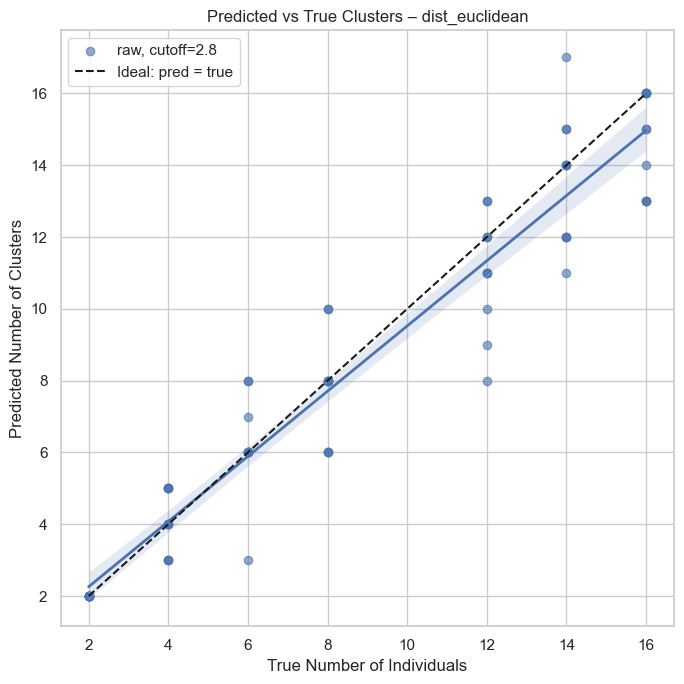

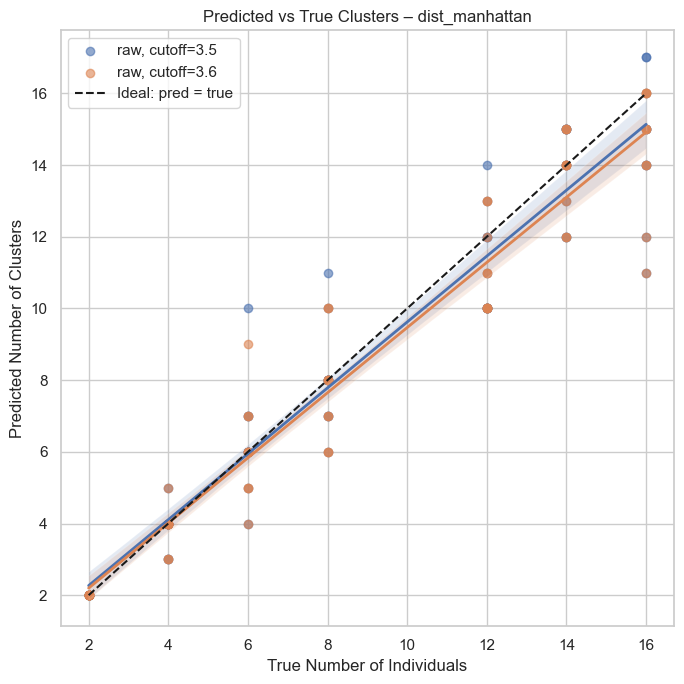

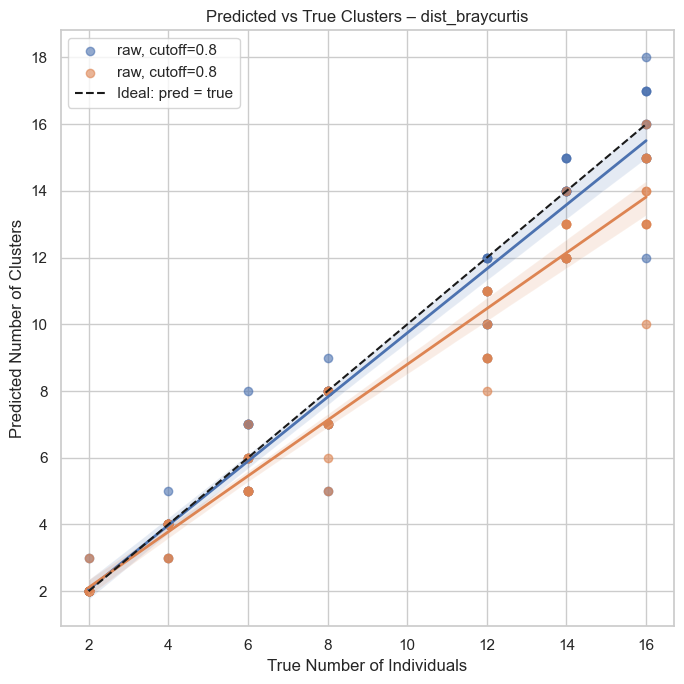

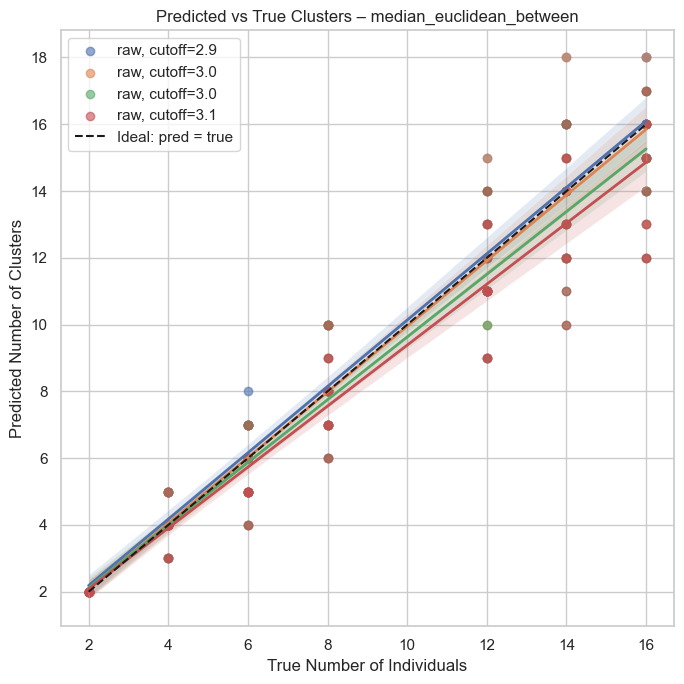

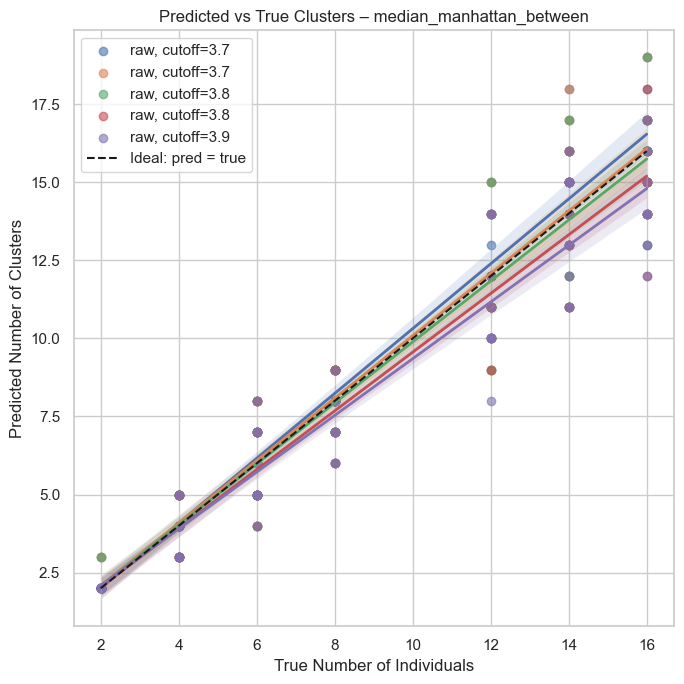

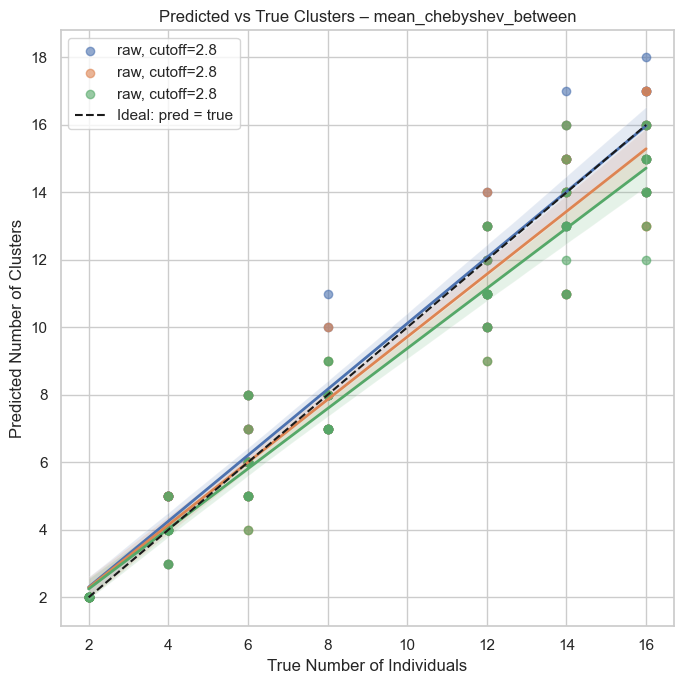

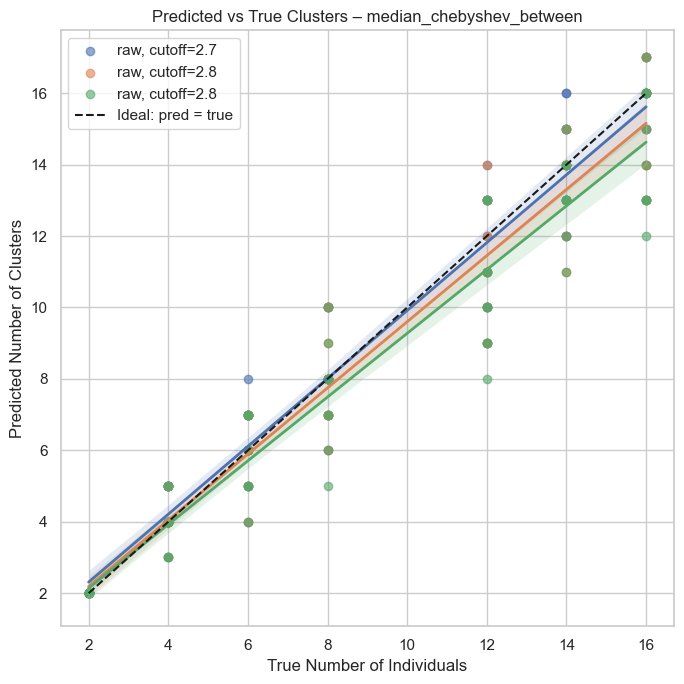

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Parameter ===
cutoff_fp = out_dir / "eurasian_otter_train_cutoff_curves.csv"
alpha = 0.5  # Gewichtung: 0.5 = gleichgewichtet ERD und V-Measure

# === CSV einlesen ===
cutoff_df = pd.read_csv(cutoff_fp)

# === Mittelwerte pro (dist_col, preprocessing, cutoff) berechnen ===
agg_df = (
    cutoff_df
    .groupby(["dist_col", "preprocessing", "cutoff"])[["erd", "v_measure"]]
    .mean()
    .reset_index()
)

# === Score berechnen ===
agg_df["score"] = alpha * (1 - agg_df["erd"]) + (1 - alpha) * agg_df["v_measure"]

# === Top-3 Kombinationen mit höchsten Scores
top3_combos = agg_df.sort_values("score", ascending=False).head(20)
print("🔎 Top 3 Kombinationen über alle Splits:")
print(top3_combos)

# === Kombinationen extrahieren
top3_params = [
    (row["dist_col"], row["preprocessing"], round(row["cutoff"], 2))
    for _, row in top3_combos.iterrows()
]

# === Gefilterten DataFrame erstellen ===
filtered_df = cutoff_df[
    cutoff_df.apply(lambda row: (row["dist_col"], row["preprocessing"], round(row["cutoff"], 2)) in top3_params, axis=1)
]

# === Plot pro Kombination ===
for dist in filtered_df["dist_col"].unique():
    df_plot = filtered_df[filtered_df["dist_col"] == dist]

    plt.figure(figsize=(7, 7))
    sns.set(style="whitegrid")

    # Punkte nach Cutoff+Prep gruppieren
    for prep in df_plot["preprocessing"].unique():
        for cutoff in df_plot["cutoff"].unique():
            sub = df_plot[(df_plot["preprocessing"] == prep) & (df_plot["cutoff"] == cutoff)]

            # Regressionsplot mit Konfidenzintervall
            sns.regplot(
                data=sub,
                x="true_n", y="pred_n",
                label=f"{prep}, cutoff={cutoff:.1f}",
                ci=95,
                scatter_kws={"alpha": 0.6},
                line_kws={"linewidth": 2}
            )

    # Diagonale
    min_n = df_plot["true_n"].min()
    max_n = df_plot["true_n"].max()
    plt.plot([min_n, max_n], [min_n, max_n], "k--", label="Ideal: pred = true")

    plt.xlabel("True Number of Individuals")
    plt.ylabel("Predicted Number of Clusters")
    plt.title(f"Predicted vs True Clusters – {dist}")
    plt.legend()
    plt.tight_layout()
    plt.show()
